In [9]:
import os
import pandas as pd
from scipy.io import loadmat
import scipy.io as sio

#match problem id from new update files with case id from previous file with origin file name
# Load the datasets
df2=pd.read_csv(r'C:\Users\wyeek\Desktop\research\westover\022013\Summary - SeizureLike Patterns\Results SeizureLike Patterns Dec 12 2022 18.50.01 PM.csv')
df6=pd.read_csv(r'C:\Users\wyeek\Desktop\research\westover\022013\Individual Reads SeizureLike Patterns\1251-all-reads_ac.csv')

# Merge the datasets on a common key column
mergeddf = pd.merge(df6, df2[["Case ID","Origin"]], left_on = ['problem_id'], right_on=['Case ID'], how="left")

# Create a new column for matchfile
mergeddf['matchfile'] = 0

# Compare the 'id' columns and update the 'matchfile' column with the origin file when the corresponding id matches
for i in range(len(mergeddf)):
    if mergeddf['Case ID'][i] == mergeddf["problem_id"][i]:
        mergeddf['matchfile'][i] = mergeddf['Origin'][i]


#process the match column to extract the last string for comparison with data folder
s=mergeddf['matchfile'].str.split('/')
mergeddf = mergeddf.assign(main=s.str[0], sub=s.str[1], leaf=s.str[-1])
mergeddf['leaf'] = mergeddf['leaf'].str.replace('.png', '')

#create a dataframe for extraction
extractdata=pd.DataFrame(mergeddf['leaf'])

C:\Users\wyeek\AppData\Local\Temp\ipykernel_2448\604794655.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mergeddf['matchfile'][i] = mergeddf['Origin'][i]
C:\Users\wyeek\AppData\Local\Temp\ipykernel_2448\604794655.py:26: FutureWarning: The default value of regex will change from True to False in a future version.
  mergeddf['leaf'] = mergeddf['leaf'].str.replace('.png', '')


In [2]:
#Create a list of all the .mat files within the root folder and its subfolders:

import os

root_folder = r'E:\Data'

# Create a list of all the .mat files within the root folder and its subfolders
mat_files = []
for folder, subfolders, files in os.walk(root_folder):
    for file in files:
        if file.endswith('.mat'):
            mat_files.append(os.path.join(folder, file))

filename_column = mergeddf['leaf']

#Filter the list of .mat files based on matching filenames:
matching_files = []

# Filter the list of .mat files based on matching filenames
for mat_file in mat_files:
    # Extract the filename without the extension
    mat_filename = os.path.basename(mat_file).rstrip('.mat')
    
    # Check if the mat_filename matches any of the filenames in the filename_column
    if mat_filename in filename_column.values:
        matching_files.append(mat_file)

#Extract data from the matching .mat files:
matching_data = []


# Extract data from the matching .mat files
for matching_file in matching_files:
    data = loadmat(matching_file)
    
    # Extract the data that you want
    # For example, if you want to extract a variable named 'my_variable'
    my_variable_data = data['votes']
    
    # Append the extracted data to a list
    matching_data.append(my_variable_data)

df_goldstandard = pd.DataFrame({'filename': matching_files, 'extracted_data': matching_data})

df_goldstandard.to_csv('df_goldstandard.csv', index=False)


In [3]:
print(df_goldstandard)

                                              filename         extracted_data
0      E:\Data\batch01\emu84_20170404_201510_12832.mat   [[0, 3, 0, 0, 0, 0]]
1     E:\Data\batch01\emu325_20161203_072913_10180.mat   [[0, 3, 0, 0, 0, 0]]
2      E:\Data\batch01\emu73_20170426_010659_10504.mat   [[0, 4, 0, 7, 0, 0]]
3       E:\Data\batch01\emu52_20161207_130552_3605.mat   [[0, 4, 0, 3, 0, 6]]
4       E:\Data\batch01\emu52_20161207_130552_3593.mat   [[0, 4, 0, 3, 0, 6]]
...                                                ...                    ...
4385  E:\Data\batch19\sid923_20130216_001116_14412.mat   [[0, 0, 0, 0, 3, 0]]
4386  E:\Data\batch19\sid915_20140802_224627_13093.mat   [[0, 0, 0, 0, 3, 0]]
4387   E:\Data\batch19\sid914_20150928_085450_1290.mat   [[0, 0, 0, 0, 0, 3]]
4388  E:\Data\batch19\sid983_20150209_173848_17744.mat  [[2, 0, 12, 3, 0, 0]]
4389  E:\Data\batch19\sid923_20130215_101756_21446.mat  [[1, 2, 1, 1, 18, 1]]

[4390 rows x 2 columns]


In [4]:
print(mergeddf)

               id  user_id  problem_id  topic_id  \
0        39735033    25929     4947254      1251   
1        39735041    25929     4947271      1251   
2        39735046    25929     4947256      1251   
3        39735050    25929     4947266      1251   
4        39751600       26     4947262      1251   
...           ...      ...         ...       ...   
657320  184757150   327346     4971692      1251   
657321  184757162   327346     4965629      1251   
657322  184757170   327346     4972357      1251   
657323  184757181   327346     4958716      1251   
657324  185494401   328081     4972357      1251   

                           created_at                     updated_at  \
0       2021-04-13 16:40:46.580799+00  2021-04-13 16:40:46.580799+00   
1        2021-04-13 16:40:50.16695+00   2021-04-13 16:40:50.16695+00   
2       2021-04-13 16:40:52.039751+00  2021-04-13 16:40:52.039751+00   
3       2021-04-13 16:40:53.272636+00  2021-04-13 16:40:53.272636+00   
4       2021-04

In [24]:
df_extracted['extracted_data'] = df_extracted['extracted_data'].astype(str)

# Use the str accessor and the replace function to remove the unwanted characters
df_extracted['extracted_data2'] = df_extracted['extracted_data'].apply(lambda x: x.strip('[]'))

# Use the str accessor and the replace function to remove all commas
df_extracted2['extracted_data'] = df_extracted2['extracted_data'].apply(lambda x: x.strip(','))

# Print the updated dataframe
print(df_extracted2)

NameError: name 'df_extracted2' is not defined

In [ ]:
#Create a list of all the .mat files within the root folder and its subfolders:

import os

root_folder = r'E:\Data'

# Create a list of all the .mat files within the root folder and its subfolders
mat_files = []
for folder, subfolders, files in os.walk(root_folder):
    for file in files:
        if file.endswith('.mat'):
            mat_files.append(os.path.join(folder, file))

filename_column = mergeddf['leaf']

#Filter the list of .mat files based on matching filenames:
matching_files = []

# Filter the list of .mat files based on matching filenames
for mat_file in mat_files:
    # Extract the filename without the extension
    mat_filename = os.path.basename(mat_file).rstrip('.mat')
    
    # Check if the mat_filename matches any of the filenames in the filename_column
    if mat_filename in filename_column.values:
        matching_files.append(mat_file)

#Extract data from the matching .mat files:
matching_data = []


# Extract data from the matching .mat files
for matching_file in matching_files:
    data = loadmat(matching_file)
    
    # Extract the data that you want
    # For example, if you want to extract a variable named 'my_variable'
    my_variable_data = data['votes']
    
    # Append the extracted data to a list
    matching_data.append(my_variable_data)

df_extracted = pd.DataFrame({'filename': matching_files, 'extracted_data': matching_data})


In [3]:
#process the dataframe to remove / and . 
import pandas as pd
dfextracted=pd.read_csv(r'C:\Users\wyeek\Desktop\research\python\jupyter lab test\df_extracted.csv')
dfextracted['filename2']=dfextracted['filename'].str.extract(r'\\(.*?)\.')
dfextracted2= dfextracted['filename2'].str.rsplit(pat='\\', n=1, expand=True)
dfextracted2.columns = ['path', 'filename']
dfextracted['filename3']=dfextracted2['filename']
print(dfextracted)

                                              filename         extracted_data  \
0      E:\Data\batch01\emu84_20170404_201510_12832.mat        [[0 3 0 0 0 0]]   
1     E:\Data\batch01\emu325_20161203_072913_10180.mat        [[0 3 0 0 0 0]]   
2      E:\Data\batch01\emu73_20170426_010659_10504.mat        [[0 4 0 7 0 0]]   
3       E:\Data\batch01\emu52_20161207_130552_3605.mat        [[0 4 0 3 0 6]]   
4       E:\Data\batch01\emu52_20161207_130552_3593.mat        [[0 4 0 3 0 6]]   
...                                                ...                    ...   
4385  E:\Data\batch19\sid923_20130216_001116_14412.mat        [[0 0 0 0 3 0]]   
4386  E:\Data\batch19\sid915_20140802_224627_13093.mat        [[0 0 0 0 3 0]]   
4387   E:\Data\batch19\sid914_20150928_085450_1290.mat        [[0 0 0 0 0 3]]   
4388  E:\Data\batch19\sid983_20150209_173848_17744.mat  [[ 2  0 12  3  0  0]]   
4389  E:\Data\batch19\sid923_20130215_101756_21446.mat  [[ 1  2  1  1 18  1]]   

                           

In [4]:
dfextracted[['Other', 'Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA']] = dfextracted['extracted_data'].str.strip('[]').str.split(expand=True)

dfextracted

,filename,extracted_data,filename2,filename3,Other,Seizure,LPD,GPD,LRDA,GRDA
0,E:\Data\batch01\emu84_20170404_201510_12832.mat,[[0 3 0 0 0 0]],Data\batch01\emu84_20170404_201510_12832,emu84_20170404_201510_12832,0,3,0,0,0,0
1,E:\Data\batch01\emu325_20161203_072913_10180.mat,[[0 3 0 0 0 0]],Data\batch01\emu325_20161203_072913_10180,emu325_20161203_072913_10180,0,3,0,0,0,0
2,E:\Data\batch01\emu73_20170426_010659_10504.mat,[[0 4 0 7 0 0]],Data\batch01\emu73_20170426_010659_10504,emu73_20170426_010659_10504,0,4,0,7,0,0
3,E:\Data\batch01\emu52_20161207_130552_3605.mat,[[0 4 0 3 0 6]],Data\batch01\emu52_20161207_130552_3605,emu52_20161207_130552_3605,0,4,0,3,0,6
4,E:\Data\batch01\emu52_20161207_130552_3593.mat,[[0 4 0 3 0 6]],Data\batch01\emu52_20161207_130552_3593,emu52_20161207_130552_3593,0,4,0,3,0,6
...,...,...,...,...,...,...,...,...,...,...
4385,E:\Data\batch19\sid923_20130216_001116_14412.mat,[[0 0 0 0 3 0]],Data\batch19\sid923_20130216_001116_14412,sid923_20130216_001116_14412,0,0,0,0,3,0
4386,E:\Data\batch19\sid915_20140802_224627_13093.mat,[[0 0 0 0 3 0]],Data\batch19\sid915_20140802_224627_13093,sid915_20140802_224627_13093,0,0,0,0,3,0
4387,E:\Data\batch19\sid914_20150928_085450_1290.mat,[[0 0 0 0 0 3]],Data\batch19\sid914_20150928_085450_1290,sid914_20150928_085450_1290,0,0,0,0,0,3
4388,E:\Data\batch19\sid983_20150209_173848_17744.mat,[[ 2 0 12 3 0 0]],Data\batch19\sid983_20150209_173848_17744,sid983_20150209_173848_17744,2,0,12,3,0,0


In [5]:
dfextracted[['other', 'seizure', 'lpd', 'gpd', 'lrda', 'grda']] = dfextracted[['Other', 'Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA']].astype(int)

In [8]:
# define a function to apply to each row
def max_col(row):
    return row.idxmax()

# apply it to each row and create a new column in the DataFrame
dfextracted['max_column'] = dfextracted[['other', 'seizure', 'lpd', 'gpd', 'lrda', 'grda']].apply(lambda row: max_col(row), axis=1)
dfextracted

,filename,extracted_data,filename2,filename3,Other,Seizure,LPD,GPD,LRDA,GRDA,other,seizure,lpd,gpd,lrda,grda,max_column
0,E:\Data\batch01\emu84_20170404_201510_12832.mat,[[0 3 0 0 0 0]],Data\batch01\emu84_20170404_201510_12832,emu84_20170404_201510_12832,0,3,0,0,0,0,0,3,0,0,0,0,seizure
1,E:\Data\batch01\emu325_20161203_072913_10180.mat,[[0 3 0 0 0 0]],Data\batch01\emu325_20161203_072913_10180,emu325_20161203_072913_10180,0,3,0,0,0,0,0,3,0,0,0,0,seizure
2,E:\Data\batch01\emu73_20170426_010659_10504.mat,[[0 4 0 7 0 0]],Data\batch01\emu73_20170426_010659_10504,emu73_20170426_010659_10504,0,4,0,7,0,0,0,4,0,7,0,0,gpd
3,E:\Data\batch01\emu52_20161207_130552_3605.mat,[[0 4 0 3 0 6]],Data\batch01\emu52_20161207_130552_3605,emu52_20161207_130552_3605,0,4,0,3,0,6,0,4,0,3,0,6,grda
4,E:\Data\batch01\emu52_20161207_130552_3593.mat,[[0 4 0 3 0 6]],Data\batch01\emu52_20161207_130552_3593,emu52_20161207_130552_3593,0,4,0,3,0,6,0,4,0,3,0,6,grda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4385,E:\Data\batch19\sid923_20130216_001116_14412.mat,[[0 0 0 0 3 0]],Data\batch19\sid923_20130216_001116_14412,sid923_20130216_001116_14412,0,0,0,0,3,0,0,0,0,0,3,0,lrda
4386,E:\Data\batch19\sid915_20140802_224627_13093.mat,[[0 0 0 0 3 0]],Data\batch19\sid915_20140802_224627_13093,sid915_20140802_224627_13093,0,0,0,0,3,0,0,0,0,0,3,0,lrda
4387,E:\Data\batch19\sid914_20150928_085450_1290.mat,[[0 0 0 0 0 3]],Data\batch19\sid914_20150928_085450_1290,sid914_20150928_085450_1290,0,0,0,0,0,3,0,0,0,0,0,3,grda
4388,E:\Data\batch19\sid983_20150209_173848_17744.mat,[[ 2 0 12 3 0 0]],Data\batch19\sid983_20150209_173848_17744,sid983_20150209_173848_17744,2,0,12,3,0,0,2,0,12,3,0,0,lpd


In [10]:
df_gs = pd.merge(mergeddf, dfextracted[["filename3","max_column"]], left_on = ['leaf'], right_on=['filename3'], how="left")


In [74]:
df_gs['leaf'].count() 

630296

In [12]:
df_gs.loc[df_gs['max_column'].isna(), 'findgs'] = df_gs['Origin']

In [13]:
df_gs

,id,user_id,problem_id,topic_id,created_at,updated_at,problem_appeared_at,response_submitted_at,duration,answerChoiceIds,...,mission_id,Case ID,Origin,matchfile,main,sub,leaf,filename3,max_column,findgs
0,39735033,25929,4947254,1251,2021-04-13 16:40:46.580799+00,2021-04-13 16:40:46.580799+00,2021-04-13 16:40:43.553+00,2021-04-13 16:40:46.448999+00,NaN,{18201051},...,NaN,4947254.0,E275A23F-C8BC-4A56-93C6-1914D0D1998C/other/abn...,E275A23F-C8BC-4A56-93C6-1914D0D1998C/other/abn...,E275A23F-C8BC-4A56-93C6-1914D0D1998C,other,abn276_20130830_080124_3,abn276_20130830_080124_3,other,NaN
1,39735041,25929,4947271,1251,2021-04-13 16:40:50.16695+00,2021-04-13 16:40:50.16695+00,2021-04-13 16:40:47.500999+00,2021-04-13 16:40:50.032+00,NaN,{18201381},...,NaN,4947271.0,EE635EAD-1BA7-47E7-94A0-2BD274D8C90D/GRDA/abn2...,EE635EAD-1BA7-47E7-94A0-2BD274D8C90D/GRDA/abn2...,EE635EAD-1BA7-47E7-94A0-2BD274D8C90D,GRDA,abn2077_20140602_080753_2119 copy,NaN,NaN,EE635EAD-1BA7-47E7-94A0-2BD274D8C90D/GRDA/abn2...
2,39735046,25929,4947256,1251,2021-04-13 16:40:52.039751+00,2021-04-13 16:40:52.039751+00,2021-04-13 16:40:51.31+00,2021-04-13 16:40:51.904+00,NaN,{18201314},...,NaN,4947256.0,77FACEF1-7C9B-43FB-A1C4-7E26858433A6/LPD/abn29...,77FACEF1-7C9B-43FB-A1C4-7E26858433A6/LPD/abn29...,77FACEF1-7C9B-43FB-A1C4-7E26858433A6,LPD,abn2947_20140224_081349_2047 copy,NaN,NaN,77FACEF1-7C9B-43FB-A1C4-7E26858433A6/LPD/abn29...
3,39735050,25929,4947266,1251,2021-04-13 16:40:53.272636+00,2021-04-13 16:40:53.272636+00,2021-04-13 16:40:52.515+00,2021-04-13 16:40:53.118+00,NaN,{18201396},...,NaN,4947266.0,0369D393-F3D9-4B1F-9F4A-DEC8646D3284/GPD/abn19...,0369D393-F3D9-4B1F-9F4A-DEC8646D3284/GPD/abn19...,0369D393-F3D9-4B1F-9F4A-DEC8646D3284,GPD,abn1967_20110629_101448_751 copy,NaN,NaN,0369D393-F3D9-4B1F-9F4A-DEC8646D3284/GPD/abn19...
4,39751600,26,4947262,1251,2021-04-13 18:09:38.667927+00,2021-04-13 18:09:38.667927+00,2021-04-13 18:09:27.628+00,2021-04-13 18:09:38.563+00,NaN,{18201337},...,NaN,4947262.0,B94BEA27-2131-445D-82FF-C68BBBF9C584/LRDA/abn1...,B94BEA27-2131-445D-82FF-C68BBBF9C584/LRDA/abn1...,B94BEA27-2131-445D-82FF-C68BBBF9C584,LRDA,abn10490_20140819_082501_1161 copy,NaN,NaN,B94BEA27-2131-445D-82FF-C68BBBF9C584/LRDA/abn1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657320,184757150,327346,4971692,1251,2023-03-25 09:08:38.332456+00,2023-03-25 09:08:38.332456+00,2023-03-25 09:08:33.22+00,2023-03-25 09:08:38.102+00,4.874181,{18624292},...,NaN,4971692.0,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,https:,,pat1306_20160425_121053_8402,NaN,NaN,https://centaur-customer-uploads.s3.us-east-1....
657321,184757162,327346,4965629,1251,2023-03-25 09:08:45.017418+00,2023-03-25 09:08:45.017418+00,2023-03-25 09:08:39.617+00,2023-03-25 09:08:44.786+00,5.161455,{18413272},...,NaN,4965629.0,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,https:,,sid1056_20170421_144806_1450,sid1056_20170421_144806_1450,lpd,NaN
657322,184757170,327346,4972357,1251,2023-03-25 09:08:49.986751+00,2023-03-25 09:08:49.986751+00,2023-03-25 09:08:46.67+00,2023-03-25 09:08:49.767999+00,3.091391,{18556638},...,NaN,4972357.0,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,https:,,sid246_20150902_061650_3507,sid246_20150902_061650_3507,lrda,NaN
657323,184757181,327346,4958716,1251,2023-03-25 09:08:54.319597+00,2023-03-25 09:08:54.319597+00,2023-03-25 09:08:51.036+00,2023-03-25 09:08:54.095+00,3.051244,{23697673},...,NaN,4958716.0,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,https:,,sid1309_20140805_091940_18286,sid1309_20140805_091940_18286,gpd,NaN


In [14]:
df_gs2 = pd.merge(df_gs, df2[["Origin","Correct Label"]], left_on = ['findgs'], right_on=['Origin'], how="left")
df_gs2['Correct Label'] =  df_gs2['Correct Label'].str.replace("'","")

In [15]:
df_gs2

,id,user_id,problem_id,topic_id,created_at,updated_at,problem_appeared_at,response_submitted_at,duration,answerChoiceIds,...,Origin_x,matchfile,main,sub,leaf,filename3,max_column,findgs,Origin_y,Correct Label
0,39735033,25929,4947254,1251,2021-04-13 16:40:46.580799+00,2021-04-13 16:40:46.580799+00,2021-04-13 16:40:43.553+00,2021-04-13 16:40:46.448999+00,NaN,{18201051},...,E275A23F-C8BC-4A56-93C6-1914D0D1998C/other/abn...,E275A23F-C8BC-4A56-93C6-1914D0D1998C/other/abn...,E275A23F-C8BC-4A56-93C6-1914D0D1998C,other,abn276_20130830_080124_3,abn276_20130830_080124_3,other,NaN,NaN,NaN
1,39735041,25929,4947271,1251,2021-04-13 16:40:50.16695+00,2021-04-13 16:40:50.16695+00,2021-04-13 16:40:47.500999+00,2021-04-13 16:40:50.032+00,NaN,{18201381},...,EE635EAD-1BA7-47E7-94A0-2BD274D8C90D/GRDA/abn2...,EE635EAD-1BA7-47E7-94A0-2BD274D8C90D/GRDA/abn2...,EE635EAD-1BA7-47E7-94A0-2BD274D8C90D,GRDA,abn2077_20140602_080753_2119 copy,NaN,NaN,EE635EAD-1BA7-47E7-94A0-2BD274D8C90D/GRDA/abn2...,EE635EAD-1BA7-47E7-94A0-2BD274D8C90D/GRDA/abn2...,grda
2,39735046,25929,4947256,1251,2021-04-13 16:40:52.039751+00,2021-04-13 16:40:52.039751+00,2021-04-13 16:40:51.31+00,2021-04-13 16:40:51.904+00,NaN,{18201314},...,77FACEF1-7C9B-43FB-A1C4-7E26858433A6/LPD/abn29...,77FACEF1-7C9B-43FB-A1C4-7E26858433A6/LPD/abn29...,77FACEF1-7C9B-43FB-A1C4-7E26858433A6,LPD,abn2947_20140224_081349_2047 copy,NaN,NaN,77FACEF1-7C9B-43FB-A1C4-7E26858433A6/LPD/abn29...,77FACEF1-7C9B-43FB-A1C4-7E26858433A6/LPD/abn29...,lpd
3,39735050,25929,4947266,1251,2021-04-13 16:40:53.272636+00,2021-04-13 16:40:53.272636+00,2021-04-13 16:40:52.515+00,2021-04-13 16:40:53.118+00,NaN,{18201396},...,0369D393-F3D9-4B1F-9F4A-DEC8646D3284/GPD/abn19...,0369D393-F3D9-4B1F-9F4A-DEC8646D3284/GPD/abn19...,0369D393-F3D9-4B1F-9F4A-DEC8646D3284,GPD,abn1967_20110629_101448_751 copy,NaN,NaN,0369D393-F3D9-4B1F-9F4A-DEC8646D3284/GPD/abn19...,0369D393-F3D9-4B1F-9F4A-DEC8646D3284/GPD/abn19...,gpd
4,39751600,26,4947262,1251,2021-04-13 18:09:38.667927+00,2021-04-13 18:09:38.667927+00,2021-04-13 18:09:27.628+00,2021-04-13 18:09:38.563+00,NaN,{18201337},...,B94BEA27-2131-445D-82FF-C68BBBF9C584/LRDA/abn1...,B94BEA27-2131-445D-82FF-C68BBBF9C584/LRDA/abn1...,B94BEA27-2131-445D-82FF-C68BBBF9C584,LRDA,abn10490_20140819_082501_1161 copy,NaN,NaN,B94BEA27-2131-445D-82FF-C68BBBF9C584/LRDA/abn1...,B94BEA27-2131-445D-82FF-C68BBBF9C584/LRDA/abn1...,lrda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657320,184757150,327346,4971692,1251,2023-03-25 09:08:38.332456+00,2023-03-25 09:08:38.332456+00,2023-03-25 09:08:33.22+00,2023-03-25 09:08:38.102+00,4.874181,{18624292},...,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,https:,,pat1306_20160425_121053_8402,NaN,NaN,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,NaN
657321,184757162,327346,4965629,1251,2023-03-25 09:08:45.017418+00,2023-03-25 09:08:45.017418+00,2023-03-25 09:08:39.617+00,2023-03-25 09:08:44.786+00,5.161455,{18413272},...,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,https:,,sid1056_20170421_144806_1450,sid1056_20170421_144806_1450,lpd,NaN,NaN,NaN
657322,184757170,327346,4972357,1251,2023-03-25 09:08:49.986751+00,2023-03-25 09:08:49.986751+00,2023-03-25 09:08:46.67+00,2023-03-25 09:08:49.767999+00,3.091391,{18556638},...,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,https:,,sid246_20150902_061650_3507,sid246_20150902_061650_3507,lrda,NaN,NaN,NaN
657323,184757181,327346,4958716,1251,2023-03-25 09:08:54.319597+00,2023-03-25 09:08:54.319597+00,2023-03-25 09:08:51.036+00,2023-03-25 09:08:54.095+00,3.051244,{23697673},...,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,https:,,sid1309_20140805_091940_18286,sid1309_20140805_091940_18286,gpd,NaN,NaN,NaN


In [16]:
import numpy as np  
df_gs2['goldstandardnew'] = np.where(df_gs2['max_column'].isnull(), df_gs2['Correct Label'], df_gs2['max_column'])

In [110]:
print(df_gs2)

               id  user_id  problem_id  topic_id  \
0        39735033    25929     4947254      1251   
1        39735041    25929     4947271      1251   
2        39735046    25929     4947256      1251   
3        39735050    25929     4947266      1251   
4        39751600       26     4947262      1251   
...           ...      ...         ...       ...   
657320  184757150   327346     4971692      1251   
657321  184757162   327346     4965629      1251   
657322  184757170   327346     4972357      1251   
657323  184757181   327346     4958716      1251   
657324  185494401   328081     4972357      1251   

                           created_at                     updated_at  \
0       2021-04-13 16:40:46.580799+00  2021-04-13 16:40:46.580799+00   
1        2021-04-13 16:40:50.16695+00   2021-04-13 16:40:50.16695+00   
2       2021-04-13 16:40:52.039751+00  2021-04-13 16:40:52.039751+00   
3       2021-04-13 16:40:53.272636+00  2021-04-13 16:40:53.272636+00   
4       2021-04

In [107]:
df_gs2.to_csv('df_gs2.csv', index=False)

In [1]:
import pandas as pd
df2_gs2=pd.read_csv(r'C:/Users/wyeek/Desktop/research/python/jupyter lab test/df_gs2.csv')


C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\1101141834.py:2: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df2_gs2=pd.read_csv(r'C:/Users/wyeek/Desktop/research/python/jupyter lab test/df_gs2.csv')


In [17]:
df1=pd.read_csv(r'C:\Users\wyeek\Desktop\research\westover\629\eeg-all-users-and-topics.csv')

In [20]:
df_gs3 = pd.merge(df2_gs2, df1[["id","preferred_specialty",'experience_level']], left_on = ['user_id'], right_on=['id'], how="left")

In [4]:
df_gs3.to_csv('completewithgoldstandard.csv',index=False)

In [4]:
df_gs3=pd.read_csv(r'C:\Users\wyeek\Desktop\research\python\jupyter lab test\completewithgoldstandard.csv')

C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\434162331.py:1: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gs3=pd.read_csv(r'C:\Users\wyeek\Desktop\research\python\jupyter lab test\completewithgoldstandard.csv')


In [5]:
#create datafrane for each experience level
other = df_gs3[df_gs3['experience_level'] == 'Other']
NPPApharmacist=df_gs3[(df_gs3['experience_level']=='NP')|(df_gs3['experience_level']=='PA')|(df_gs3['experience_level']=='Pharmacist')]
Otherstudent=df_gs3[(df_gs3['experience_level']=='NP Student')|(df_gs3['experience_level']=='PA Student')|(df_gs3['experience_level']=='Pharmacy Student')|(df_gs3['experience_level']=='Other Healthcare Student')]
Medicalstudent=df_gs3[df_gs3['experience_level']=='Medical Student']
MD=df_gs3[(df_gs3['experience_level']=='MD')|(df_gs3['experience_level']=='DO')]
Expert=df_gs3[df_gs3['experience_level']=='Expert']

In [21]:
Expert.rename(columns={'title': 'useranswer'}, inplace=True)
Expert.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)

C:\Users\wyeek\AppData\Local\Temp\ipykernel_12500\3714473804.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Expert.rename(columns={'title': 'useranswer'}, inplace=True)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_12500\3714473804.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Expert.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)


In [22]:
Expert

,id_x,user_id,problem_id,topic_id,created_at,updated_at,problem_appeared_at,response_submitted_at,duration,answerChoiceIds,...,leaf,filename3,max_column,findgs,Origin_y,Correct Label,correctanswer,id_y,preferred_specialty,experience_level
634,43827826,41816,4965629,1251,2021-05-07 21:42:47.949418+00,2021-05-07 21:42:47.949418+00,2021-05-07 21:42:23.974999+00,2021-05-07 21:42:47.889+00,NaN,{18413272},...,sid1056_20170421_144806_1450,sid1056_20170421_144806_1450,lpd,NaN,NaN,NaN,lpd,41816.0,Epilepsy,Expert
635,43827834,41816,4964708,1251,2021-05-07 21:43:04.06385+00,2021-05-07 21:43:04.06385+00,2021-05-07 21:42:51.915999+00,2021-05-07 21:43:03.990999+00,NaN,{18685631},...,sid1056_20170421_144806_1909,NaN,NaN,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,NaN,NaN,41816.0,Epilepsy,Expert
637,43827849,41816,5011371,1251,2021-05-07 21:43:21.215027+00,2021-05-07 21:43:21.215027+00,2021-05-07 21:43:08.798+00,2021-05-07 21:43:21.16+00,NaN,{18390695},...,sid1593_20140715_152731_1304,NaN,NaN,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,NaN,NaN,41816.0,Epilepsy,Expert
638,43827855,41816,4982057,1251,2021-05-07 21:43:29.55255+00,2021-05-07 21:43:29.55255+00,2021-05-07 21:43:23.108+00,2021-05-07 21:43:29.490999+00,NaN,{18361381},...,sid673_20131210_144842_982,sid673_20131210_144842_982,other,NaN,NaN,NaN,other,41816.0,Epilepsy,Expert
639,43827862,41816,5016950,1251,2021-05-07 21:43:45.657323+00,2021-05-07 21:43:45.657323+00,2021-05-07 21:43:40.598+00,2021-05-07 21:43:45.592+00,NaN,{18396274},...,sid316_20150305_124952_1810,NaN,NaN,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,NaN,NaN,41816.0,Epilepsy,Expert
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450719,104882174,21127,4983065,1251,2021-11-21 20:00:55.148481+00,2021-11-21 20:00:55.148481+00,2021-11-21 20:00:49.691999+00,2021-11-21 20:00:54.904+00,5.203249,{18703988},...,sid781_20130924_230246_12020,sid781_20130924_230246_12020,other,NaN,NaN,NaN,other,21127.0,Epilepsy,Expert
450720,104882227,21127,4964108,1251,2021-11-21 20:01:16.186429+00,2021-11-21 20:01:16.186429+00,2021-11-21 20:01:02.579+00,2021-11-21 20:01:15.953+00,13.360247,{34668435},...,sid937_20121206_220023_772,sid937_20121206_220023_772,other,NaN,NaN,NaN,other,21127.0,Epilepsy,Expert
552512,136157649,21127,4971451,1251,2022-05-04 17:01:17.503387+00,2022-05-04 17:01:17.503387+00,2022-05-04 17:00:47.599999+00,2022-05-04 17:01:17.272+00,29.661860,{29198245},...,sid1928_20171014_123309_16716,NaN,NaN,https://centaur-customer-uploads.s3.us-east-1....,https://centaur-customer-uploads.s3.us-east-1....,lrda,lrda,21127.0,Epilepsy,Expert
552513,136157680,21127,4982057,1251,2022-05-04 17:01:50.329493+00,2022-05-04 17:01:50.329493+00,2022-05-04 17:01:30.836+00,2022-05-04 17:01:50.086999+00,19.242215,{18634657},...,sid673_20131210_144842_982,sid673_20131210_144842_982,other,NaN,NaN,NaN,other,21127.0,Epilepsy,Expert


In [24]:
Expert
import numpy as np
#creat TP TN FP FN for each pattern
conditions=[
     (Expert['useranswer']=='gpd')&(Expert['correctanswer']=='gpd'),
     (Expert['useranswer']=='gpd')&(Expert['correctanswer']!='gpd'),
     (Expert['useranswer']!='gpd')&(Expert['correctanswer']=='gpd'),
     (Expert['useranswer']!='gpd')&(Expert['correctanswer']!='gpd')
]

values=['TP','FP','FN','TN']
Expert['GPD']=np.select(conditions,values)

conditions=[
     (Expert['useranswer']=='lpd')&(Expert['correctanswer']=='lpd'),
     (Expert['useranswer']=='lpd')&(Expert['correctanswer']!='lpd'),
     (Expert['useranswer']!='lpd')&(Expert['correctanswer']=='lpd'),
     (Expert['useranswer']!='lpd')&(Expert['correctanswer']!='lpd')
]

values=['TP','FP','FN','TN']
Expert['LPD']=np.select(conditions,values)

conditions=[
     (Expert['useranswer']=='lrda')&(Expert['correctanswer']=='lrda'),
     (Expert['useranswer']=='lrda')&(Expert['correctanswer']!='lrda'),
     (Expert['useranswer']!='lrda')&(Expert['correctanswer']=='lrda'),
     (Expert['useranswer']!='lrda')&(Expert['correctanswer']!='lrda')
]

values=['TP','FP','FN','TN']
Expert['lrda']=np.select(conditions,values)

conditions=[
     (Expert['useranswer']=='grda')&(Expert['correctanswer']=='grda'),
     (Expert['useranswer']=='grda')&(Expert['correctanswer']!='grda'),
     (Expert['useranswer']!='grda')&(Expert['correctanswer']=='grda'),
     (Expert['useranswer']!='grda')&(Expert['correctanswer']!='grda')
]

values=['TP','FP','FN','TN']
Expert['grda']=np.select(conditions,values)

conditions=[
     (Expert['useranswer']=='seizure')&(Expert['correctanswer']=='seizure'),
     (Expert['useranswer']=='seizure')&(Expert['correctanswer']!='seizure'),
     (Expert['useranswer']!='seizure')&(Expert['correctanswer']=='seizure'),
     (Expert['useranswer']!='seizure')&(Expert['correctanswer']!='seizure')
]

values=['TP','FP','FN','TN']
Expert['seizure']=np.select(conditions,values)

conditions=[
     (Expert['useranswer']=='other')&(Expert['correctanswer']=='other'),
     (Expert['useranswer']=='other')&(Expert['correctanswer']!='other'),
     (Expert['useranswer']!='other')&(Expert['correctanswer']=='other'),
     (Expert['useranswer']!='other')&(Expert['correctanswer']!='other')
]

values=['TP','FP','FN','TN']
Expert['other']=np.select(conditions,values)

C:\Users\wyeek\AppData\Local\Temp\ipykernel_12500\1512772037.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Expert['GPD']=np.select(conditions,values)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_12500\1512772037.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Expert['LPD']=np.select(conditions,values)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_12500\1512772037.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

In [30]:
Expert

,id_x,user_id,problem_id,topic_id,created_at,updated_at,problem_appeared_at,response_submitted_at,duration,answerChoiceIds,...,correctanswer,id_y,preferred_specialty,experience_level,GPD,LPD,lrda,grda,seizure,other
634,43827826,41816,4965629,1251,2021-05-07 21:42:47.949418+00,2021-05-07 21:42:47.949418+00,2021-05-07 21:42:23.974999+00,2021-05-07 21:42:47.889+00,NaN,{18413272},...,lpd,41816.0,Epilepsy,Expert,TN,TP,TN,TN,TN,TN
635,43827834,41816,4964708,1251,2021-05-07 21:43:04.06385+00,2021-05-07 21:43:04.06385+00,2021-05-07 21:42:51.915999+00,2021-05-07 21:43:03.990999+00,NaN,{18685631},...,NaN,41816.0,Epilepsy,Expert,TN,TN,TN,TN,TN,FP
637,43827849,41816,5011371,1251,2021-05-07 21:43:21.215027+00,2021-05-07 21:43:21.215027+00,2021-05-07 21:43:08.798+00,2021-05-07 21:43:21.16+00,NaN,{18390695},...,NaN,41816.0,Epilepsy,Expert,TN,TN,TN,TN,FP,TN
638,43827855,41816,4982057,1251,2021-05-07 21:43:29.55255+00,2021-05-07 21:43:29.55255+00,2021-05-07 21:43:23.108+00,2021-05-07 21:43:29.490999+00,NaN,{18361381},...,other,41816.0,Epilepsy,Expert,TN,TN,TN,TN,FP,FN
639,43827862,41816,5016950,1251,2021-05-07 21:43:45.657323+00,2021-05-07 21:43:45.657323+00,2021-05-07 21:43:40.598+00,2021-05-07 21:43:45.592+00,NaN,{18396274},...,NaN,41816.0,Epilepsy,Expert,TN,TN,TN,TN,FP,TN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450719,104882174,21127,4983065,1251,2021-11-21 20:00:55.148481+00,2021-11-21 20:00:55.148481+00,2021-11-21 20:00:49.691999+00,2021-11-21 20:00:54.904+00,5.203249,{18703988},...,other,21127.0,Epilepsy,Expert,TN,TN,TN,TN,TN,TP
450720,104882227,21127,4964108,1251,2021-11-21 20:01:16.186429+00,2021-11-21 20:01:16.186429+00,2021-11-21 20:01:02.579+00,2021-11-21 20:01:15.953+00,13.360247,{34668435},...,other,21127.0,Epilepsy,Expert,TN,TN,FP,TN,TN,FN
552512,136157649,21127,4971451,1251,2022-05-04 17:01:17.503387+00,2022-05-04 17:01:17.503387+00,2022-05-04 17:00:47.599999+00,2022-05-04 17:01:17.272+00,29.661860,{29198245},...,lrda,21127.0,Epilepsy,Expert,TN,TN,TP,TN,TN,TN
552513,136157680,21127,4982057,1251,2022-05-04 17:01:50.329493+00,2022-05-04 17:01:50.329493+00,2022-05-04 17:01:30.836+00,2022-05-04 17:01:50.086999+00,19.242215,{18634657},...,other,21127.0,Epilepsy,Expert,TN,TN,TN,FP,TN,FN


<AxesSubplot: xlabel='FPR', ylabel='TPR'>

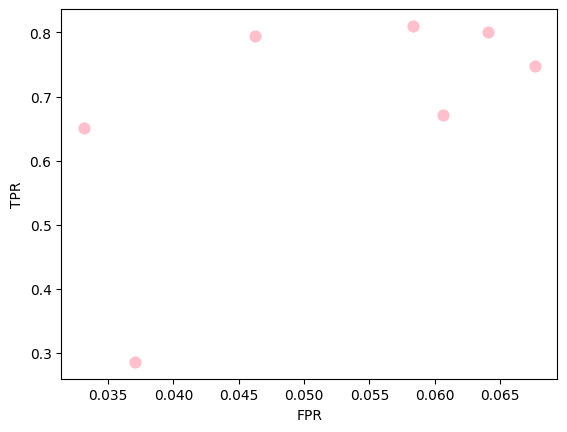

In [33]:
#create scatter plot
GPDE=Expert[['user_id', 'GPD']].value_counts().reset_index(name='GPDcounts')
GPDE2 = GPDE.pivot_table('GPDcounts', ['user_id'], 'GPD')
GPDE2['TPR']=GPDE2['TP']/(GPDE2['TP']+GPDE2['FN'])
GPDE2['FPR']=GPDE2['FP']/(GPDE2['FP']+GPDE2['TN'])
color='pink'
GPDE2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

<AxesSubplot: xlabel='FPR', ylabel='TPR'>

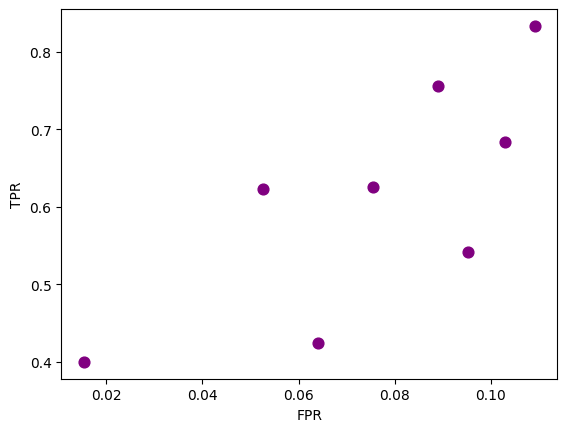

In [34]:
LPDE1=Expert[['user_id', 'LPD']].value_counts().reset_index(name='LPDcounts')
LPDE2 = LPDE1.pivot_table('LPDcounts', ['user_id'], 'LPD')
LPDE2['TPR']=LPDE2['TP']/(LPDE2['TP']+LPDE2['FN'])
LPDE2['FPR']=LPDE2['FP']/(LPDE2['FP']+LPDE2['TN'])
color='purple'
LPDE2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

<AxesSubplot: xlabel='FPR', ylabel='TPR'>

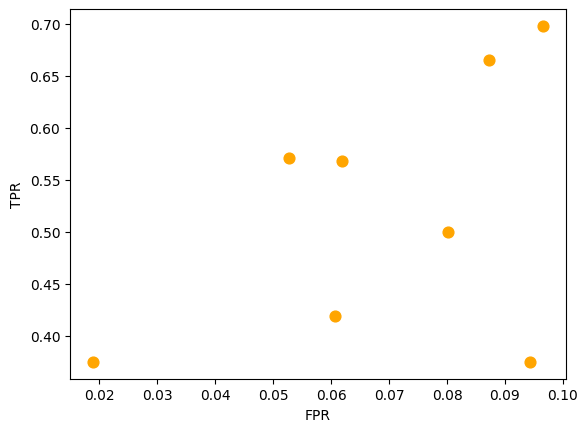

In [36]:
LRDAE1=Expert[['user_id', 'lrda']].value_counts().reset_index(name='LRDAcounts')
LRDAE2 = LRDAE1.pivot_table('LRDAcounts', ['user_id'], 'lrda')
LRDAE2['TPR']=LRDAE2['TP']/(LRDAE2['TP']+LRDAE2['FN'])
LRDAE2['FPR']=LRDAE2['FP']/(LRDAE2['FP']+LRDAE2['TN'])
color='orange'
LRDAE2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

<AxesSubplot: xlabel='FPR', ylabel='TPR'>

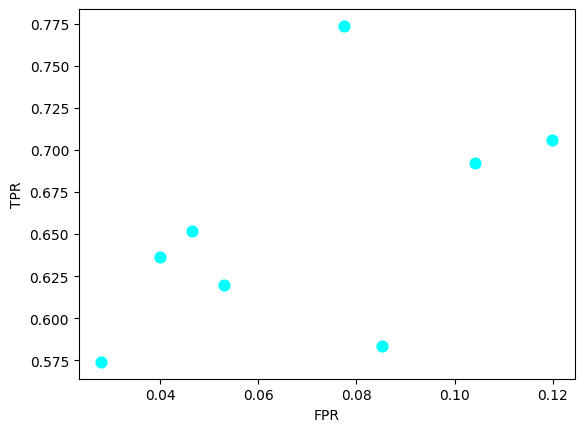

In [38]:
GRDAE1=Expert[['user_id', 'grda']].value_counts().reset_index(name='GRDAcounts')
GRDAE2 = GRDAE1.pivot_table('GRDAcounts', ['user_id'], 'grda')
GRDAE2['TPR']=GRDAE2['TP']/(GRDAE2['TP']+GRDAE2['FN'])
GRDAE2['FPR']=GRDAE2['FP']/(GRDAE2['FP']+GRDAE2['TN'])
color='aqua'
GRDAE2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

<AxesSubplot: xlabel='FPR', ylabel='TPR'>

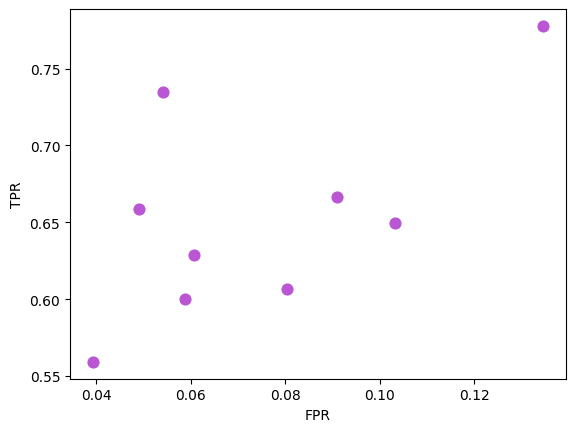

In [40]:
seizureE1=Expert[['user_id', 'seizure']].value_counts().reset_index(name='seizurecounts')
seizureE2 = seizureE1.pivot_table('seizurecounts', ['user_id'], 'seizure')
seizureE2['TPR']=seizureE2['TP']/(seizureE2['TP']+seizureE2['FN'])
seizureE2['FPR']=seizureE2['FP']/(seizureE2['FP']+seizureE2['TN'])
color='mediumorchid'
seizureE2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c= color)

<AxesSubplot: xlabel='FPR', ylabel='TPR'>

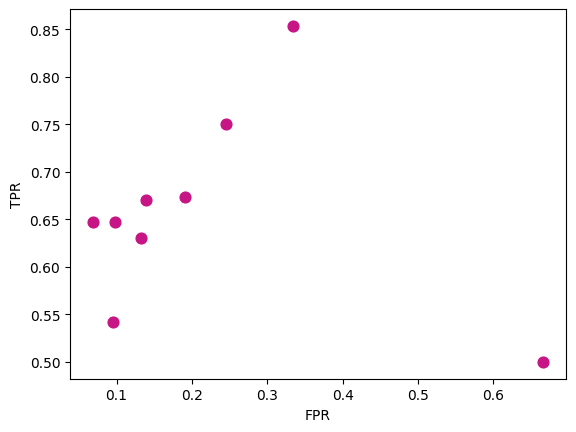

In [41]:
otherE1=Expert[['user_id', 'other']].value_counts().reset_index(name='othercounts')
otherE2 = otherE1.pivot_table('othercounts', ['user_id'], 'other')
otherE2['TPR']=otherE2['TP']/(otherE2['TP']+otherE2['FN'])
otherE2['FPR']=otherE2['FP']/(otherE2['FP']+otherE2['TN'])
color='mediumvioletred'
otherE2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

In [43]:
LPDE2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\LPDE2.csv', index=True, header=True)
GRDAE2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\grdaE2.csv', index=True, header=True)
LRDAE2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\lrdaE2.csv', index=True, header=True)
seizureE2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\seizureE2.csv', index=True, header=True)
GPDE2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\GPDE2.csv', index=True, header=True)
otherE2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\otherE2.csv', index=True, header=True)

C:\Users\wyeek\AppData\Local\Temp\ipykernel_12500\42053083.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Medicalstudent.rename(columns={'title': 'useranswer'}, inplace=True)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_12500\42053083.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Medicalstudent.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_12500\42053083.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

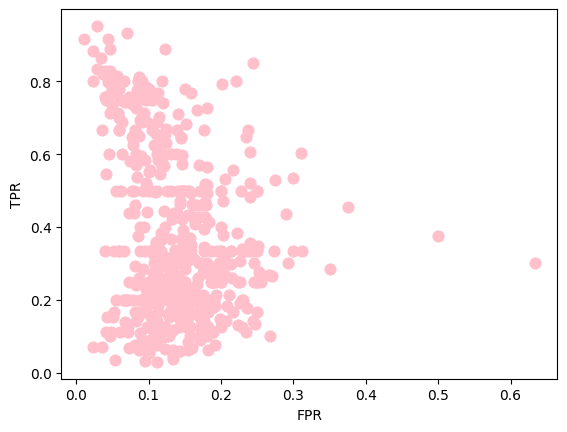

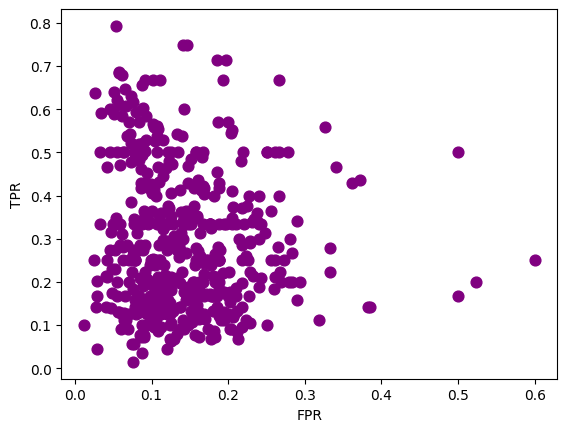

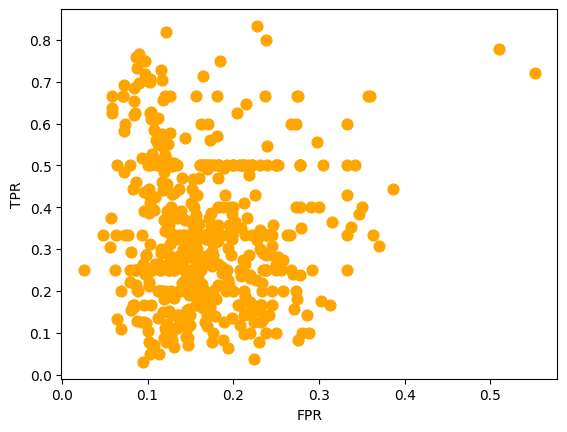

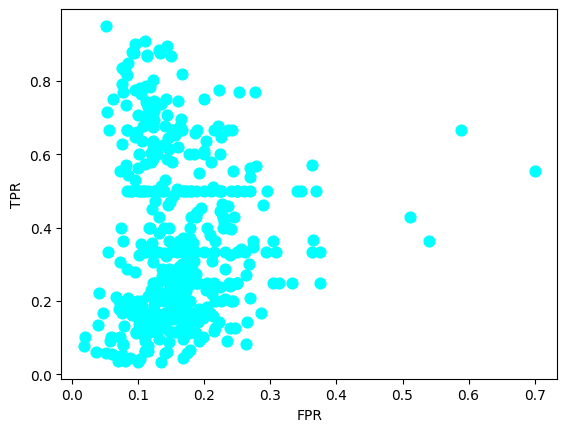

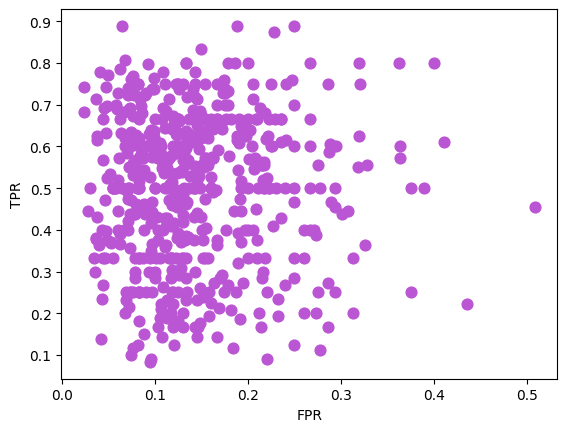

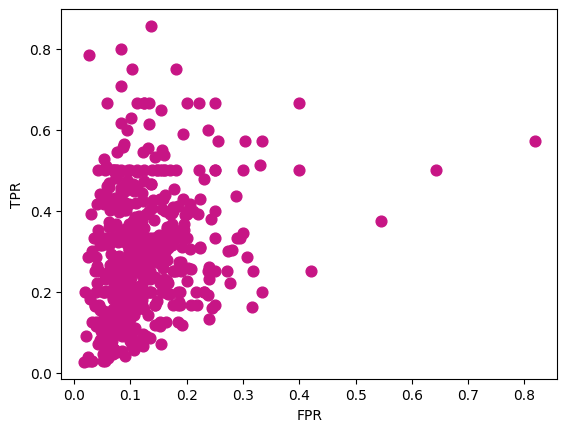

In [49]:
#Students
Medicalstudent.rename(columns={'title': 'useranswer'}, inplace=True)
Medicalstudent.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)
#creat TP TN FP FN for each pattern
conditions=[
     (Medicalstudent['useranswer']=='gpd')&(Medicalstudent['correctanswer']=='gpd'),
     (Medicalstudent['useranswer']=='gpd')&(Medicalstudent['correctanswer']!='gpd'),
     (Medicalstudent['useranswer']!='gpd')&(Medicalstudent['correctanswer']=='gpd'),
     (Medicalstudent['useranswer']!='gpd')&(Medicalstudent['correctanswer']!='gpd')
]

values=['TP','FP','FN','TN']
Medicalstudent['GPD']=np.select(conditions,values)

conditions=[
     (Medicalstudent['useranswer']=='lpd')&(Medicalstudent['correctanswer']=='lpd'),
     (Medicalstudent['useranswer']=='lpd')&(Medicalstudent['correctanswer']!='lpd'),
     (Medicalstudent['useranswer']!='lpd')&(Medicalstudent['correctanswer']=='lpd'),
     (Medicalstudent['useranswer']!='lpd')&(Medicalstudent['correctanswer']!='lpd')
]

values=['TP','FP','FN','TN']
Medicalstudent['LPD']=np.select(conditions,values)

conditions=[
     (Medicalstudent['useranswer']=='lrda')&(Medicalstudent['correctanswer']=='lrda'),
     (Medicalstudent['useranswer']=='lrda')&(Medicalstudent['correctanswer']!='lrda'),
     (Medicalstudent['useranswer']!='lrda')&(Medicalstudent['correctanswer']=='lrda'),
     (Medicalstudent['useranswer']!='lrda')&(Medicalstudent['correctanswer']!='lrda')
]

values=['TP','FP','FN','TN']
Medicalstudent['lrda']=np.select(conditions,values)

conditions=[
     (Medicalstudent['useranswer']=='grda')&(Medicalstudent['correctanswer']=='grda'),
     (Medicalstudent['useranswer']=='grda')&(Medicalstudent['correctanswer']!='grda'),
     (Medicalstudent['useranswer']!='grda')&(Medicalstudent['correctanswer']=='grda'),
     (Medicalstudent['useranswer']!='grda')&(Medicalstudent['correctanswer']!='grda')
]

values=['TP','FP','FN','TN']
Medicalstudent['grda']=np.select(conditions,values)

conditions=[
     (Medicalstudent['useranswer']=='seizure')&(Medicalstudent['correctanswer']=='seizure'),
     (Medicalstudent['useranswer']=='seizure')&(Medicalstudent['correctanswer']!='seizure'),
     (Medicalstudent['useranswer']!='seizure')&(Medicalstudent['correctanswer']=='seizure'),
     (Medicalstudent['useranswer']!='seizure')&(Medicalstudent['correctanswer']!='seizure')
]

values=['TP','FP','FN','TN']
Medicalstudent['seizure']=np.select(conditions,values)

conditions=[
     (Medicalstudent['useranswer']=='other')&(Medicalstudent['correctanswer']=='other'),
     (Medicalstudent['useranswer']=='other')&(Medicalstudent['correctanswer']!='other'),
     (Medicalstudent['useranswer']!='other')&(Medicalstudent['correctanswer']=='other'),
     (Medicalstudent['useranswer']!='other')&(Medicalstudent['correctanswer']!='other')
]

values=['TP','FP','FN','TN']
Medicalstudent['other']=np.select(conditions,values)

#create scatter plot
GPDMS1=Medicalstudent[['user_id', 'GPD']].value_counts().reset_index(name='GPDcounts')
GPDMS2 = GPDMS1.pivot_table('GPDcounts', ['user_id'], 'GPD')
GPDMS2['TPR']=GPDMS2['TP']/(GPDMS2['TP']+GPDMS2['FN'])
GPDMS2['FPR']=GPDMS2['FP']/(GPDMS2['FP']+GPDMS2['TN'])
color='pink'
GPDMS2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LPDMS1=Medicalstudent[['user_id', 'LPD']].value_counts().reset_index(name='LPDcounts')
LPDMS2 = LPDMS1.pivot_table('LPDcounts', ['user_id'], 'LPD')
LPDMS2['TPR']=LPDMS2['TP']/(LPDMS2['TP']+LPDMS2['FN'])
LPDMS2['FPR']=LPDMS2['FP']/(LPDMS2['FP']+LPDMS2['TN'])
color='purple'
LPDMS2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LRDAMS1=Medicalstudent[['user_id', 'lrda']].value_counts().reset_index(name='LRDAcounts')
LRDAMS2 = LRDAMS1.pivot_table('LRDAcounts', ['user_id'], 'lrda')
LRDAMS2['TPR']=LRDAMS2['TP']/(LRDAMS2['TP']+LRDAMS2['FN'])
LRDAMS2['FPR']=LRDAMS2['FP']/(LRDAMS2['FP']+LRDAMS2['TN'])
color='orange'
LRDAMS2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

GRDAMS1=Medicalstudent[['user_id', 'grda']].value_counts().reset_index(name='GRDAcounts')
GRDAMS2 = GRDAMS1.pivot_table('GRDAcounts', ['user_id'], 'grda')
GRDAMS2['TPR']=GRDAMS2['TP']/(GRDAMS2['TP']+GRDAMS2['FN'])
GRDAMS2['FPR']=GRDAMS2['FP']/(GRDAMS2['FP']+GRDAMS2['TN'])
color='aqua'
GRDAMS2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

seizureMS1=Medicalstudent[['user_id', 'seizure']].value_counts().reset_index(name='seizurecounts')
seizureMS2 = seizureMS1.pivot_table('seizurecounts', ['user_id'], 'seizure')
seizureMS2['TPR']=seizureMS2['TP']/(seizureMS2['TP']+seizureMS2['FN'])
seizureMS2['FPR']=seizureMS2['FP']/(seizureMS2['FP']+seizureMS2['TN'])
color='mediumorchid'
seizureMS2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c= color)

otherMS1=Medicalstudent[['user_id', 'other']].value_counts().reset_index(name='othercounts')
otherMS2 = otherMS1.pivot_table('othercounts', ['user_id'], 'other')
otherMS2['TPR']=otherMS2['TP']/(otherMS2['TP']+otherMS2['FN'])
otherMS2['FPR']=otherMS2['FP']/(otherMS2['FP']+otherMS2['TN'])
color='mediumvioletred'
otherMS2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LPDMS2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\LPDMS2.csv', index=True, header=True)
GRDAMS2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\grdaMS2.csv', index=True, header=True)
LRDAMS2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\lrdaMS2.csv', index=True, header=True)
seizureMS2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\seizureMS2.csv', index=True, header=True)
GPDMS2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\GPDMS2.csv', index=True, header=True)
otherMS2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\otherMS2.csv', index=True, header=True)

In [22]:
df_gs3['useranswer']=df_gs3['title']
df_gs3['correctanswer']=df_gs3['goldstandardnew']
#creat TP TN FP FN for each pattern
conditions=[
     (df_gs3['useranswer']=='gpd')&(df_gs3['correctanswer']=='gpd'),
     (df_gs3['useranswer']=='gpd')&(df_gs3['correctanswer']!='gpd'),
     (df_gs3['useranswer']!='gpd')&(df_gs3['correctanswer']=='gpd'),
     (df_gs3['useranswer']!='gpd')&(df_gs3['correctanswer']!='gpd')
]

values=['TP','FP','FN','TN']
df_gs3['GPD']=np.select(conditions,values)

conditions=[
     (df_gs3['useranswer']=='lpd')&(df_gs3['correctanswer']=='lpd'),
     (df_gs3['useranswer']=='lpd')&(df_gs3['correctanswer']!='lpd'),
     (df_gs3['useranswer']!='lpd')&(df_gs3['correctanswer']=='lpd'),
     (df_gs3['useranswer']!='lpd')&(df_gs3['correctanswer']!='lpd')
]

values=['TP','FP','FN','TN']
df_gs3['LPD']=np.select(conditions,values)

conditions=[
     (Medicalstudent['useranswer']=='lrda')&(Medicalstudent['correctanswer']=='lrda'),
     (Medicalstudent['useranswer']=='lrda')&(Medicalstudent['correctanswer']!='lrda'),
     (Medicalstudent['useranswer']!='lrda')&(Medicalstudent['correctanswer']=='lrda'),
     (Medicalstudent['useranswer']!='lrda')&(Medicalstudent['correctanswer']!='lrda')
]

values=['TP','FP','FN','TN']
Medicalstudent['lrda']=np.select(conditions,values)

conditions=[
     (df_gs3['useranswer']=='grda')&(df_gs3['correctanswer']=='grda'),
     (df_gs3['useranswer']=='grda')&(df_gs3['correctanswer']!='grda'),
     (df_gs3['useranswer']!='grda')&(df_gs3['correctanswer']=='grda'),
     (df_gs3['useranswer']!='grda')&(df_gs3['correctanswer']!='grda')
]

values=['TP','FP','FN','TN']
df_gs3['grda']=np.select(conditions,values)

conditions=[
     (df_gs3['useranswer']=='seizure')&(df_gs3['correctanswer']=='seizure'),
     (df_gs3['useranswer']=='seizure')&(df_gs3['correctanswer']!='seizure'),
     (df_gs3['useranswer']!='seizure')&(df_gs3['correctanswer']=='seizure'),
     (df_gs3['useranswer']!='seizure')&(df_gs3['correctanswer']!='seizure')
]

values=['TP','FP','FN','TN']
df_gs3['seizure']=np.select(conditions,values)

conditions=[
     (df_gs3['useranswer']=='other')&(df_gs3['correctanswer']=='other'),
     (df_gs3['useranswer']=='other')&(df_gs3['correctanswer']!='other'),
     (df_gs3['useranswer']!='other')&(df_gs3['correctanswer']=='other'),
     (df_gs3['useranswer']!='other')&(df_gs3['correctanswer']!='other')
]

values=['TP','FP','FN','TN']
df_gs3['other']=np.select(conditions,values)


KeyError: 'useranswer'

In [23]:
import seaborn as sns

#create scatter plot
GPDALL1=df_gs3[['user_id', 'GPD']].value_counts().reset_index(name='GPDcounts')
GPDALL2 = GPDALL1.pivot_table('GPDcounts', ['user_id'], 'GPD')
GPDALL2['TPR']=GPDALL2['TP']/(GPDALL2['TP']+GPDALL2['FN'])
GPDALL2['FPR']=GPDALL2['FP']/(GPDALL2['FP']+GPDALL2['TN'])
conditions=[
     (GPDALL2['experience_level']=='Other'),
     (GPDALL2['experience_level']=='NP')|(GPDALL2['experience_level']=='PA')|(GPDALL2['experience_level']=='Pharmacist'),
     (GPDALL2['experience_level']=='NP Student')|(GPDALL2['experience_level']=='PA Student')|(GPDALL2['experience_level']=='Pharmacy Student')|(GPDALL2['experience_level']=='Other Healthcare Student'),
     (GPDALL2['experience_level']=='Medical Student'),
     (GPDALL2['experience_level']=='MD')|(GPDALL2['experience_level']=='DO'),
    ]
values=['other','NP/PA/pharmacist','Otherstudent','Medical Student','MD/DO']
GPDALL2['experiencelevel']=np.select(conditions,values)
sns.relplot(x='FPR', y='TPR', hue='experience_level', data=GPDALL2, kind='scatter',height=15, aspect=20/15)

LPDALL1=df_gs3[['user_id', 'LPD']].value_counts().reset_index(name='LPDcounts')
LPDALL2 = LPDALL1.pivot_table('LPDcounts', ['user_id'], 'LPD')
LPDALL2['TPR']=LPDALL2['TP']/(LPDALL2['TP']+LPDALL2['FN'])
LPDALL2['FPR']=LPDALL2['FP']/(LPDALL2['FP']+LPDALL2['TN'])

LRDAALL1=df_gs3[['user_id', 'lrda']].value_counts().reset_index(name='LRDAcounts')
LRDAALL2 = LRDAALL1.pivot_table('LRDAcounts', ['user_id'], 'lrda')
LRDAALL2['TPR']=LRDAALL2['TP']/(LRDAALL2['TP']+LRDAALL2['FN'])
LRDAALL2['FPR']=LRDAALL2['FP']/(LRDAALL2['FP']+LRDAALL2['TN'])

GRDAALL1=df_gs3[['user_id', 'grda']].value_counts().reset_index(name='GRDAcounts')
GRDAALL2 = GRDAALL1.pivot_table('GRDAcounts', ['user_id'], 'grda')
GRDAALL2 ['TPR']=GRDAALL2 ['TP']/(GRDAALL2 ['TP']+GRDAALL2['FN'])
GRDAALL2 ['FPR']=GRDAALL2 ['FP']/(GRDAALL2 ['FP']+GRDAALL2['TN'])

seizureALL1=df_gs3[['user_id', 'seizure']].value_counts().reset_index(name='seizurecounts')
seizureALL2 = seizureALL1.pivot_table('seizurecounts', ['user_id'], 'seizure')
seizureALL2['TPR']=seizureALL2['TP']/(seizureALL2['TP']+seizureALL2['FN'])
seizureALL2['FPR']=seizureALL2['FP']/(seizureALL2['FP']+seizureALL2['TN'])

otherALL1=df_gs3[['user_id', 'other']].value_counts().reset_index(name='othercounts')
otherALL2 = otherALL1.pivot_table('othercounts', ['user_id'], 'other')
otherALL2['TPR']=otherALL2['TP']/(otherALL2['TP']+otherALL2['FN'])
otherALL2['FPR']=otherALL2['FP']/(otherALL2['FP']+otherALL2['TN'])




KeyError: 'experience_level'

In [54]:
df_gs3['experience_level'].astype['string']

TypeError: 'method' object is not subscriptable

C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\824201698.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MD.rename(columns={'title': 'useranswer'}, inplace=True)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\824201698.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MD.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\824201698.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

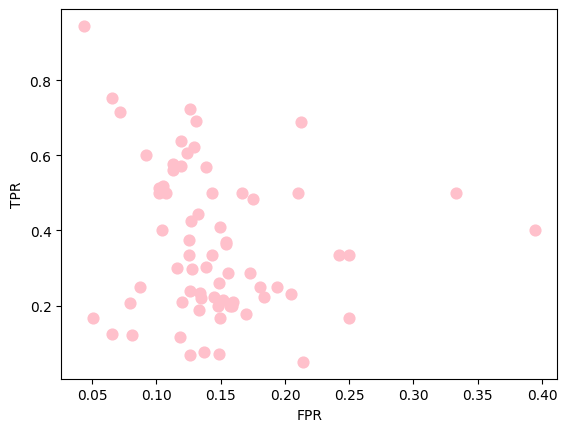

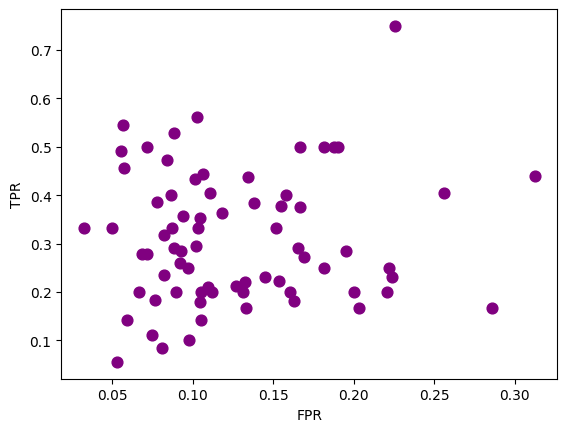

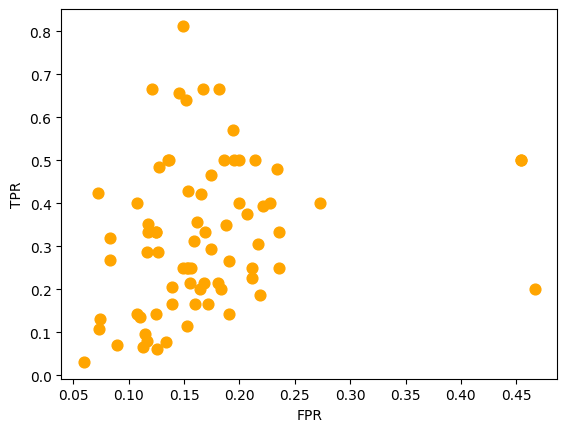

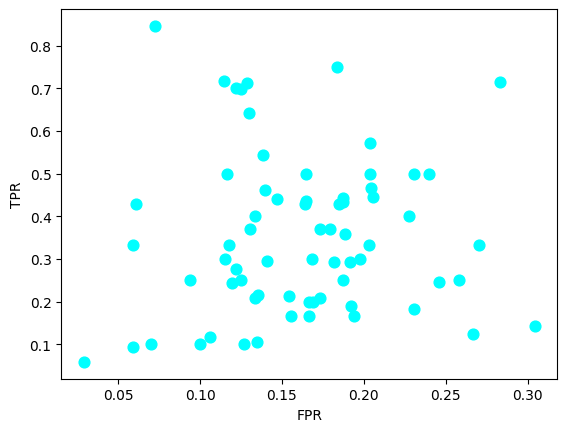

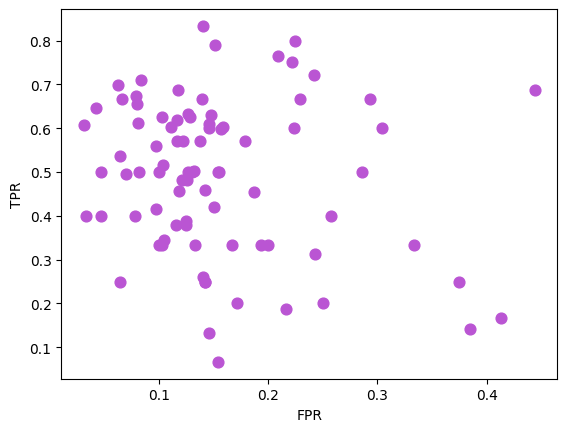

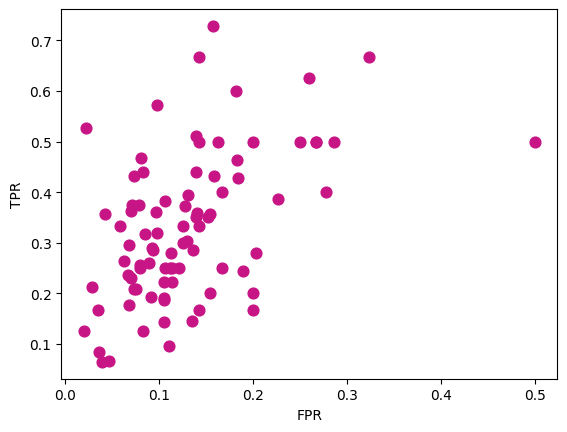

In [8]:
import numpy as np
#Students
MD.rename(columns={'title': 'useranswer'}, inplace=True)
MD.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)
#creat TP TN FP FN for each pattern
conditions=[
     (MD['useranswer']=='gpd')&(MD['correctanswer']=='gpd'),
     (MD['useranswer']=='gpd')&(MD['correctanswer']!='gpd'),
     (MD['useranswer']!='gpd')&(MD['correctanswer']=='gpd'),
     (MD['useranswer']!='gpd')&(MD['correctanswer']!='gpd')
]

values=['TP','FP','FN','TN']
MD['GPD']=np.select(conditions,values)

conditions=[
     (MD['useranswer']=='lpd')&(MD['correctanswer']=='lpd'),
     (MD['useranswer']=='lpd')&(MD['correctanswer']!='lpd'),
     (MD['useranswer']!='lpd')&(MD['correctanswer']=='lpd'),
     (MD['useranswer']!='lpd')&(MD['correctanswer']!='lpd')
]

values=['TP','FP','FN','TN']
MD['LPD']=np.select(conditions,values)

conditions=[
     (MD['useranswer']=='lrda')&(MD['correctanswer']=='lrda'),
     (MD['useranswer']=='lrda')&(MD['correctanswer']!='lrda'),
     (MD['useranswer']!='lrda')&(MD['correctanswer']=='lrda'),
     (MD['useranswer']!='lrda')&(MD['correctanswer']!='lrda')
]

values=['TP','FP','FN','TN']
MD['lrda']=np.select(conditions,values)

conditions=[
     (MD['useranswer']=='grda')&(MD['correctanswer']=='grda'),
     (MD['useranswer']=='grda')&(MD['correctanswer']!='grda'),
     (MD['useranswer']!='grda')&(MD['correctanswer']=='grda'),
     (MD['useranswer']!='grda')&(MD['correctanswer']!='grda')
]

values=['TP','FP','FN','TN']
MD['grda']=np.select(conditions,values)

conditions=[
     (MD['useranswer']=='seizure')&(MD['correctanswer']=='seizure'),
     (MD['useranswer']=='seizure')&(MD['correctanswer']!='seizure'),
     (MD['useranswer']!='seizure')&(MD['correctanswer']=='seizure'),
     (MD['useranswer']!='seizure')&(MD['correctanswer']!='seizure')
]

values=['TP','FP','FN','TN']
MD['seizure']=np.select(conditions,values)

conditions=[
     (MD['useranswer']=='other')&(MD['correctanswer']=='other'),
     (MD['useranswer']=='other')&(MD['correctanswer']!='other'),
     (MD['useranswer']!='other')&(MD['correctanswer']=='other'),
     (MD['useranswer']!='other')&(MD['correctanswer']!='other')
]

values=['TP','FP','FN','TN']
MD['other']=np.select(conditions,values)

#create scatter plot
GPDMD1=MD[['user_id', 'GPD']].value_counts().reset_index(name='GPDcounts')
GPDMD2 = GPDMD1.pivot_table('GPDcounts', ['user_id'], 'GPD')
GPDMD2['TPR']=GPDMD2['TP']/(GPDMD2['TP']+GPDMD2['FN'])
GPDMD2['FPR']=GPDMD2['FP']/(GPDMD2['FP']+GPDMD2['TN'])
color='pink'
GPDMD2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LPDMD1=MD[['user_id', 'LPD']].value_counts().reset_index(name='LPDcounts')
LPDMD2 = LPDMD1.pivot_table('LPDcounts', ['user_id'], 'LPD')
LPDMD2['TPR']=LPDMD2['TP']/(LPDMD2['TP']+LPDMD2['FN'])
LPDMD2['FPR']=LPDMD2['FP']/(LPDMD2['FP']+LPDMD2['TN'])
color='purple'
LPDMD2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LRDAMD1=MD[['user_id', 'lrda']].value_counts().reset_index(name='LRDAcounts')
LRDAMD2 = LRDAMD1.pivot_table('LRDAcounts', ['user_id'], 'lrda')
LRDAMD2['TPR']=LRDAMD2['TP']/(LRDAMD2['TP']+LRDAMD2['FN'])
LRDAMD2['FPR']=LRDAMD2['FP']/(LRDAMD2['FP']+LRDAMD2['TN'])
color='orange'
LRDAMD2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

GRDAMD1=MD[['user_id', 'grda']].value_counts().reset_index(name='GRDAcounts')
GRDAMD2 = GRDAMD1.pivot_table('GRDAcounts', ['user_id'], 'grda')
GRDAMD2['TPR']=GRDAMD2['TP']/(GRDAMD2['TP']+GRDAMD2['FN'])
GRDAMD2['FPR']=GRDAMD2['FP']/(GRDAMD2['FP']+GRDAMD2['TN'])
color='aqua'
GRDAMD2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

seizureMD1=MD[['user_id', 'seizure']].value_counts().reset_index(name='seizurecounts')
seizureMD2 = seizureMD1.pivot_table('seizurecounts', ['user_id'], 'seizure')
seizureMD2['TPR']=seizureMD2['TP']/(seizureMD2['TP']+seizureMD2['FN'])
seizureMD2['FPR']=seizureMD2['FP']/(seizureMD2['FP']+seizureMD2['TN'])
color='mediumorchid'
seizureMD2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c= color)

otherMD1=MD[['user_id', 'other']].value_counts().reset_index(name='othercounts')
otherMD2 = otherMD1.pivot_table('othercounts', ['user_id'], 'other')
otherMD2['TPR']=otherMD2['TP']/(otherMD2['TP']+otherMD2['FN'])
otherMD2['FPR']=otherMD2['FP']/(otherMD2['FP']+otherMD2['TN'])
color='mediumvioletred'
otherMD2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LPDMD2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\LPDMD2.csv', index=True, header=True)
GRDAMD2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\grdaMD2.csv', index=True, header=True)
LRDAMD2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\lrdaMD2.csv', index=True, header=True)
seizureMD2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\seizureMD2.csv', index=True, header=True)
GPDMD2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\GPDMD2.csv', index=True, header=True)
otherMD2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\otherMD2.csv', index=True, header=True)

C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\486221770.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other.rename(columns={'title': 'useranswer'}, inplace=True)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\486221770.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\486221770.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

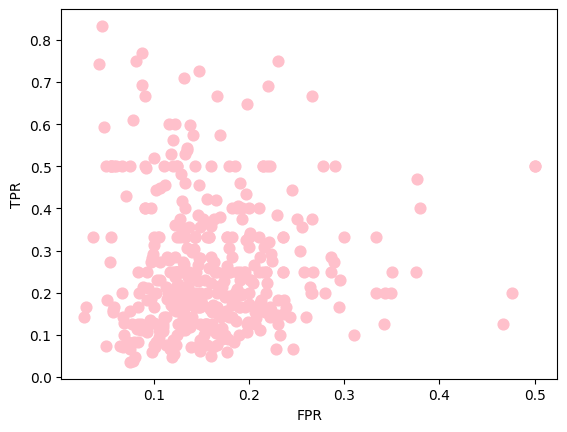

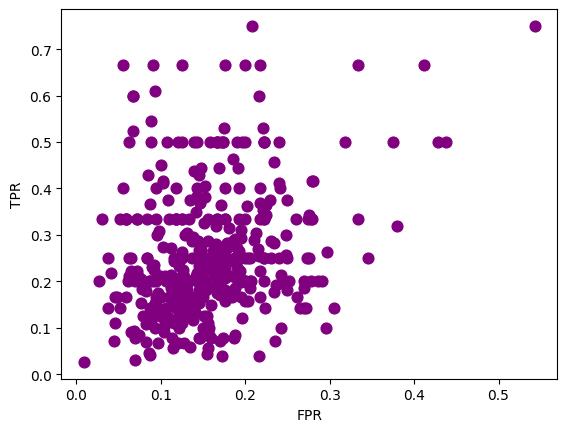

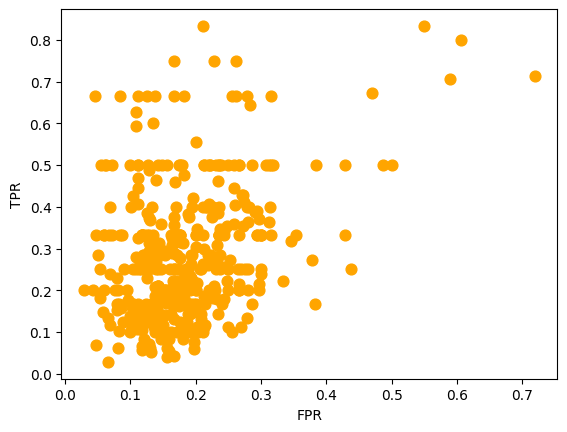

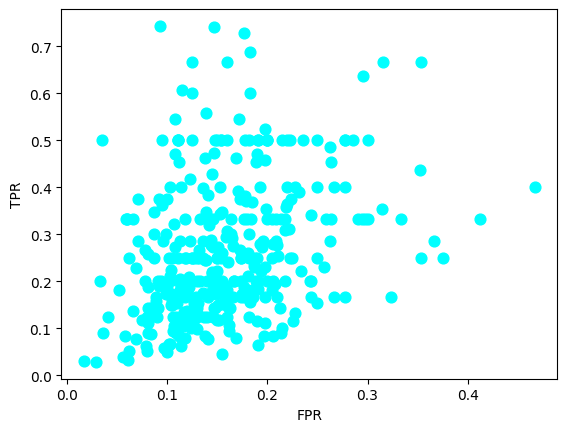

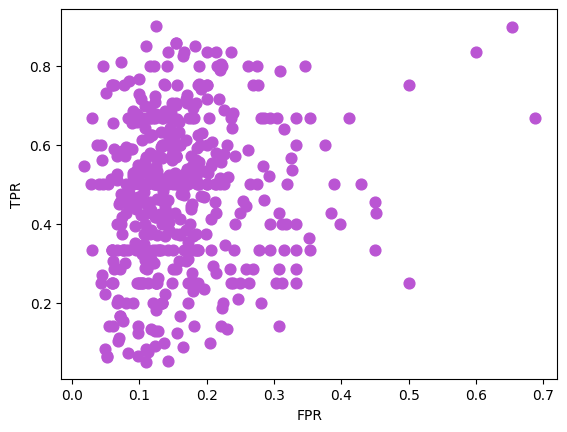

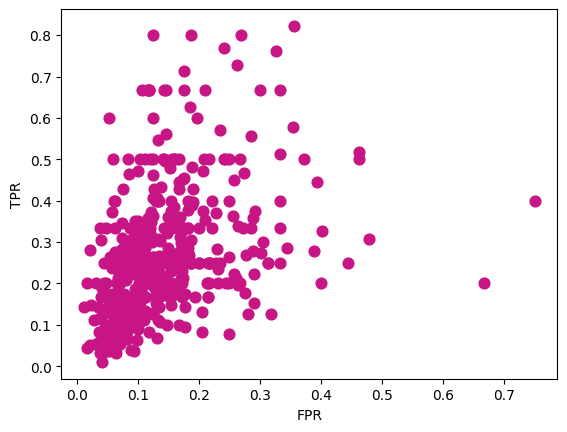

In [10]:
import numpy as np
#Students
other.rename(columns={'title': 'useranswer'}, inplace=True)
other.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)
#creat TP TN FP FN for each pattern
conditions=[
     (other['useranswer']=='gpd')&(other['correctanswer']=='gpd'),
     (other['useranswer']=='gpd')&(other['correctanswer']!='gpd'),
     (other['useranswer']!='gpd')&(other['correctanswer']=='gpd'),
     (other['useranswer']!='gpd')&(other['correctanswer']!='gpd')
]

values=['TP','FP','FN','TN']
other['GPD']=np.select(conditions,values)

conditions=[
     (other['useranswer']=='lpd')&(other['correctanswer']=='lpd'),
     (other['useranswer']=='lpd')&(other['correctanswer']!='lpd'),
     (other['useranswer']!='lpd')&(other['correctanswer']=='lpd'),
     (other['useranswer']!='lpd')&(other['correctanswer']!='lpd')
]

values=['TP','FP','FN','TN']
other['LPD']=np.select(conditions,values)

conditions=[
     (other['useranswer']=='lrda')&(other['correctanswer']=='lrda'),
     (other['useranswer']=='lrda')&(other['correctanswer']!='lrda'),
     (other['useranswer']!='lrda')&(other['correctanswer']=='lrda'),
     (other['useranswer']!='lrda')&(other['correctanswer']!='lrda')
]

values=['TP','FP','FN','TN']
other['lrda']=np.select(conditions,values)

conditions=[
     (other['useranswer']=='grda')&(other['correctanswer']=='grda'),
     (other['useranswer']=='grda')&(other['correctanswer']!='grda'),
     (other['useranswer']!='grda')&(other['correctanswer']=='grda'),
     (other['useranswer']!='grda')&(other['correctanswer']!='grda')
]

values=['TP','FP','FN','TN']
other['grda']=np.select(conditions,values)

conditions=[
     (other['useranswer']=='seizure')&(other['correctanswer']=='seizure'),
     (other['useranswer']=='seizure')&(other['correctanswer']!='seizure'),
     (other['useranswer']!='seizure')&(other['correctanswer']=='seizure'),
     (other['useranswer']!='seizure')&(other['correctanswer']!='seizure')
]

values=['TP','FP','FN','TN']
other['seizure']=np.select(conditions,values)

conditions=[
     (other['useranswer']=='other')&(other['correctanswer']=='other'),
     (other['useranswer']=='other')&(other['correctanswer']!='other'),
     (other['useranswer']!='other')&(other['correctanswer']=='other'),
     (other['useranswer']!='other')&(other['correctanswer']!='other')
]

values=['TP','FP','FN','TN']
other['other']=np.select(conditions,values)

#create scatter plot
GPDother1=other[['user_id', 'GPD']].value_counts().reset_index(name='GPDcounts')
GPDother2 = GPDother1.pivot_table('GPDcounts', ['user_id'], 'GPD')
GPDother2['TPR']=GPDother2['TP']/(GPDother2['TP']+GPDother2['FN'])
GPDother2['FPR']=GPDother2['FP']/(GPDother2['FP']+GPDother2['TN'])
color='pink'
GPDother2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LPDother1=other[['user_id', 'LPD']].value_counts().reset_index(name='LPDcounts')
LPDother2 = LPDother1.pivot_table('LPDcounts', ['user_id'], 'LPD')
LPDother2['TPR']=LPDother2['TP']/(LPDother2['TP']+LPDother2['FN'])
LPDother2['FPR']=LPDother2['FP']/(LPDother2['FP']+LPDother2['TN'])
color='purple'
LPDother2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LRDAother1=other[['user_id', 'lrda']].value_counts().reset_index(name='LRDAcounts')
LRDAother2 = LRDAother1.pivot_table('LRDAcounts', ['user_id'], 'lrda')
LRDAother2['TPR']=LRDAother2['TP']/(LRDAother2['TP']+LRDAother2['FN'])
LRDAother2['FPR']=LRDAother2['FP']/(LRDAother2['FP']+LRDAother2['TN'])
color='orange'
LRDAother2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

GRDAother1=other[['user_id', 'grda']].value_counts().reset_index(name='GRDAcounts')
GRDAother2 = GRDAother1.pivot_table('GRDAcounts', ['user_id'], 'grda')
GRDAother2['TPR']=GRDAother2['TP']/(GRDAother2['TP']+GRDAother2['FN'])
GRDAother2['FPR']=GRDAother2['FP']/(GRDAother2['FP']+GRDAother2['TN'])
color='aqua'
GRDAother2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

seizureother1=other[['user_id', 'seizure']].value_counts().reset_index(name='seizurecounts')
seizureother2 = seizureother1.pivot_table('seizurecounts', ['user_id'], 'seizure')
seizureother2['TPR']=seizureother2['TP']/(seizureother2['TP']+seizureother2['FN'])
seizureother2['FPR']=seizureother2['FP']/(seizureother2['FP']+seizureother2['TN'])
color='mediumorchid'
seizureother2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c= color)

otherother1=other[['user_id', 'other']].value_counts().reset_index(name='othercounts')
otherother2 = otherother1.pivot_table('othercounts', ['user_id'], 'other')
otherother2['TPR']=otherother2['TP']/(otherother2['TP']+otherother2['FN'])
otherother2['FPR']=otherother2['FP']/(otherother2['FP']+otherother2['TN'])
color='mediumvioletred'
otherother2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LPDother2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\LPDother2.csv', index=True, header=True)
GRDAother2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\grdaother2.csv', index=True, header=True)
LRDAother2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\lrdaother2.csv', index=True, header=True)
seizureother2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\seizureother2.csv', index=True, header=True)
GPDother2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\GPDother2.csv', index=True, header=True)
otherother2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\otherother2.csv', index=True, header=True)

C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\3148099499.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NPPApharmacist.rename(columns={'title': 'useranswer'}, inplace=True)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\3148099499.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NPPApharmacist.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\3148099499.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

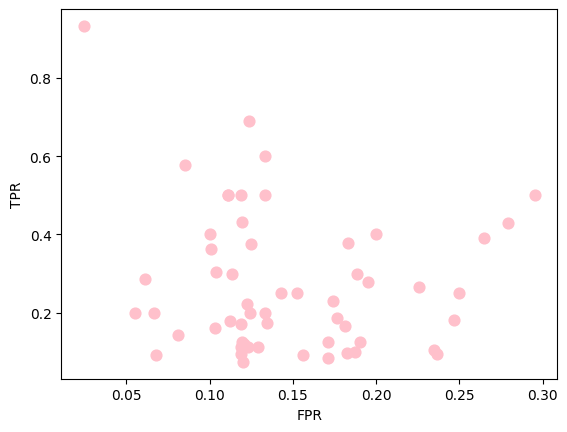

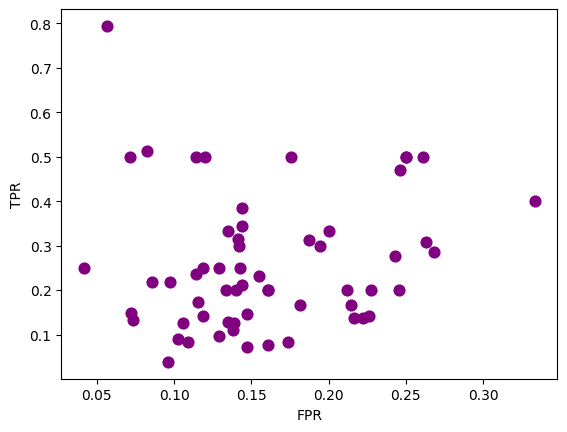

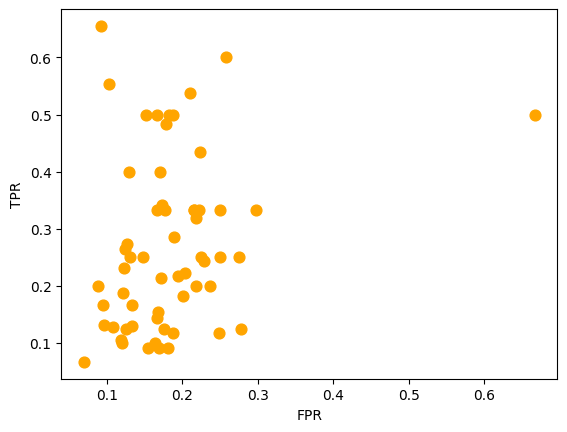

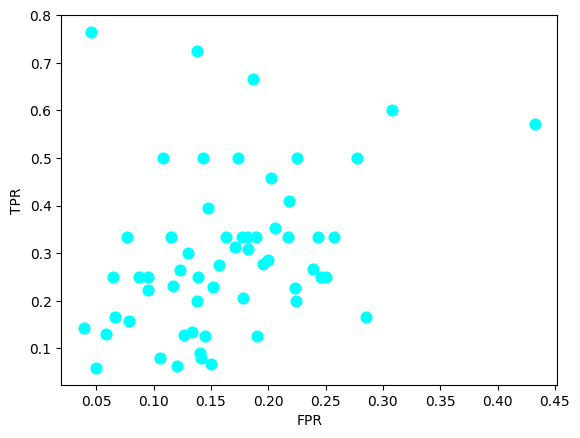

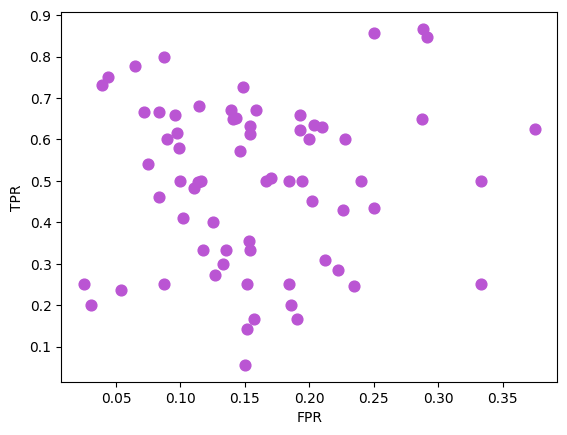

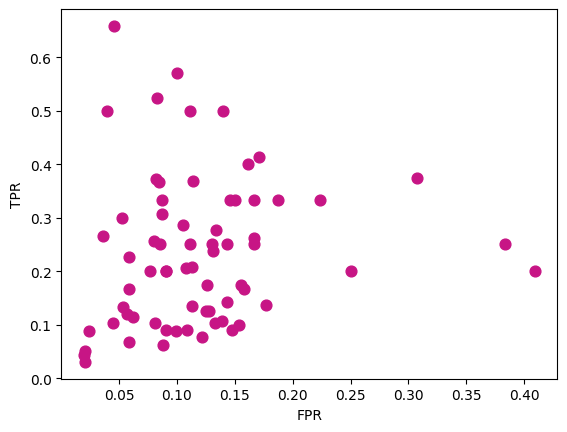

In [11]:
import numpy as np
#Students
NPPApharmacist.rename(columns={'title': 'useranswer'}, inplace=True)
NPPApharmacist.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)
#creat TP TN FP FN for each pattern
conditions=[
     (NPPApharmacist['useranswer']=='gpd')&(NPPApharmacist['correctanswer']=='gpd'),
     (NPPApharmacist['useranswer']=='gpd')&(NPPApharmacist['correctanswer']!='gpd'),
     (NPPApharmacist['useranswer']!='gpd')&(NPPApharmacist['correctanswer']=='gpd'),
     (NPPApharmacist['useranswer']!='gpd')&(NPPApharmacist['correctanswer']!='gpd')
]

values=['TP','FP','FN','TN']
NPPApharmacist['GPD']=np.select(conditions,values)

conditions=[
     (NPPApharmacist['useranswer']=='lpd')&(NPPApharmacist['correctanswer']=='lpd'),
     (NPPApharmacist['useranswer']=='lpd')&(NPPApharmacist['correctanswer']!='lpd'),
     (NPPApharmacist['useranswer']!='lpd')&(NPPApharmacist['correctanswer']=='lpd'),
     (NPPApharmacist['useranswer']!='lpd')&(NPPApharmacist['correctanswer']!='lpd')
]

values=['TP','FP','FN','TN']
NPPApharmacist['LPD']=np.select(conditions,values)

conditions=[
     (NPPApharmacist['useranswer']=='lrda')&(NPPApharmacist['correctanswer']=='lrda'),
     (NPPApharmacist['useranswer']=='lrda')&(NPPApharmacist['correctanswer']!='lrda'),
     (NPPApharmacist['useranswer']!='lrda')&(NPPApharmacist['correctanswer']=='lrda'),
     (NPPApharmacist['useranswer']!='lrda')&(NPPApharmacist['correctanswer']!='lrda')
]

values=['TP','FP','FN','TN']
NPPApharmacist['lrda']=np.select(conditions,values)

conditions=[
     (NPPApharmacist['useranswer']=='grda')&(NPPApharmacist['correctanswer']=='grda'),
     (NPPApharmacist['useranswer']=='grda')&(NPPApharmacist['correctanswer']!='grda'),
     (NPPApharmacist['useranswer']!='grda')&(NPPApharmacist['correctanswer']=='grda'),
     (NPPApharmacist['useranswer']!='grda')&(NPPApharmacist['correctanswer']!='grda')
]

values=['TP','FP','FN','TN']
NPPApharmacist['grda']=np.select(conditions,values)

conditions=[
     (NPPApharmacist['useranswer']=='seizure')&(NPPApharmacist['correctanswer']=='seizure'),
     (NPPApharmacist['useranswer']=='seizure')&(NPPApharmacist['correctanswer']!='seizure'),
     (NPPApharmacist['useranswer']!='seizure')&(NPPApharmacist['correctanswer']=='seizure'),
     (NPPApharmacist['useranswer']!='seizure')&(NPPApharmacist['correctanswer']!='seizure')
]

values=['TP','FP','FN','TN']
NPPApharmacist['seizure']=np.select(conditions,values)

conditions=[
     (NPPApharmacist['useranswer']=='other')&(NPPApharmacist['correctanswer']=='other'),
     (NPPApharmacist['useranswer']=='other')&(NPPApharmacist['correctanswer']!='other'),
     (NPPApharmacist['useranswer']!='other')&(NPPApharmacist['correctanswer']=='other'),
     (NPPApharmacist['useranswer']!='other')&(NPPApharmacist['correctanswer']!='other')
]

values=['TP','FP','FN','TN']
NPPApharmacist['other']=np.select(conditions,values)

#create scatter plot
GPDNPPApharmacist1=NPPApharmacist[['user_id', 'GPD']].value_counts().reset_index(name='GPDcounts')
GPDNPPApharmacist2 = GPDNPPApharmacist1.pivot_table('GPDcounts', ['user_id'], 'GPD')
GPDNPPApharmacist2['TPR']=GPDNPPApharmacist2['TP']/(GPDNPPApharmacist2['TP']+GPDNPPApharmacist2['FN'])
GPDNPPApharmacist2['FPR']=GPDNPPApharmacist2['FP']/(GPDNPPApharmacist2['FP']+GPDNPPApharmacist2['TN'])
color='pink'
GPDNPPApharmacist2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LPDNPPApharmacist1=NPPApharmacist[['user_id', 'LPD']].value_counts().reset_index(name='LPDcounts')
LPDNPPApharmacist2 = LPDNPPApharmacist1.pivot_table('LPDcounts', ['user_id'], 'LPD')
LPDNPPApharmacist2['TPR']=LPDNPPApharmacist2['TP']/(LPDNPPApharmacist2['TP']+LPDNPPApharmacist2['FN'])
LPDNPPApharmacist2['FPR']=LPDNPPApharmacist2['FP']/(LPDNPPApharmacist2['FP']+LPDNPPApharmacist2['TN'])
color='purple'
LPDNPPApharmacist2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LRDANPPApharmacist1=NPPApharmacist[['user_id', 'lrda']].value_counts().reset_index(name='LRDAcounts')
LRDANPPApharmacist2 = LRDANPPApharmacist1.pivot_table('LRDAcounts', ['user_id'], 'lrda')
LRDANPPApharmacist2['TPR']=LRDANPPApharmacist2['TP']/(LRDANPPApharmacist2['TP']+LRDANPPApharmacist2['FN'])
LRDANPPApharmacist2['FPR']=LRDANPPApharmacist2['FP']/(LRDANPPApharmacist2['FP']+LRDANPPApharmacist2['TN'])
color='orange'
LRDANPPApharmacist2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

GRDANPPApharmacist1=NPPApharmacist[['user_id', 'grda']].value_counts().reset_index(name='GRDAcounts')
GRDANPPApharmacist2 = GRDANPPApharmacist1.pivot_table('GRDAcounts', ['user_id'], 'grda')
GRDANPPApharmacist2['TPR']=GRDANPPApharmacist2['TP']/(GRDANPPApharmacist2['TP']+GRDANPPApharmacist2['FN'])
GRDANPPApharmacist2['FPR']=GRDANPPApharmacist2['FP']/(GRDANPPApharmacist2['FP']+GRDANPPApharmacist2['TN'])
color='aqua'
GRDANPPApharmacist2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

seizureNPPApharmacist1=NPPApharmacist[['user_id', 'seizure']].value_counts().reset_index(name='seizurecounts')
seizureNPPApharmacist2 = seizureNPPApharmacist1.pivot_table('seizurecounts', ['user_id'], 'seizure')
seizureNPPApharmacist2['TPR']=seizureNPPApharmacist2['TP']/(seizureNPPApharmacist2['TP']+seizureNPPApharmacist2['FN'])
seizureNPPApharmacist2['FPR']=seizureNPPApharmacist2['FP']/(seizureNPPApharmacist2['FP']+seizureNPPApharmacist2['TN'])
color='mediumorchid'
seizureNPPApharmacist2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c= color)

otherNPPApharmacist1=NPPApharmacist[['user_id', 'other']].value_counts().reset_index(name='othercounts')
otherNPPApharmacist2 = otherNPPApharmacist1.pivot_table('othercounts', ['user_id'], 'other')
otherNPPApharmacist2['TPR']=otherNPPApharmacist2['TP']/(otherNPPApharmacist2['TP']+otherNPPApharmacist2['FN'])
otherNPPApharmacist2['FPR']=otherNPPApharmacist2['FP']/(otherNPPApharmacist2['FP']+otherNPPApharmacist2['TN'])
color='mediumvioletred'
otherNPPApharmacist2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LPDNPPApharmacist2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\LPDNPPApharmacist2.csv', index=True, header=True)
GRDANPPApharmacist2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\grdaNPPApharmacist2.csv', index=True, header=True)
LRDANPPApharmacist2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\lrdaNPPApharmacist2.csv', index=True, header=True)
seizureNPPApharmacist2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\seizureNPPApharmacist2.csv', index=True, header=True)
GPDNPPApharmacist2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\GPDNPPApharmacist2.csv', index=True, header=True)
otherNPPApharmacist2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\otherNPPApharmacist2.csv', index=True, header=True)

C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\1462647189.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Otherstudent.rename(columns={'title': 'useranswer'}, inplace=True)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\1462647189.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Otherstudent.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)
C:\Users\wyeek\AppData\Local\Temp\ipykernel_15812\1462647189.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

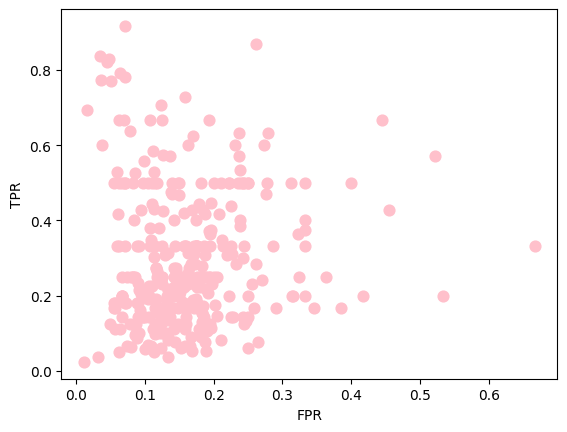

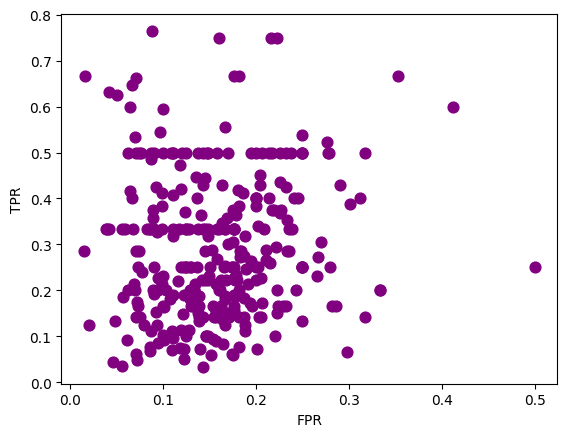

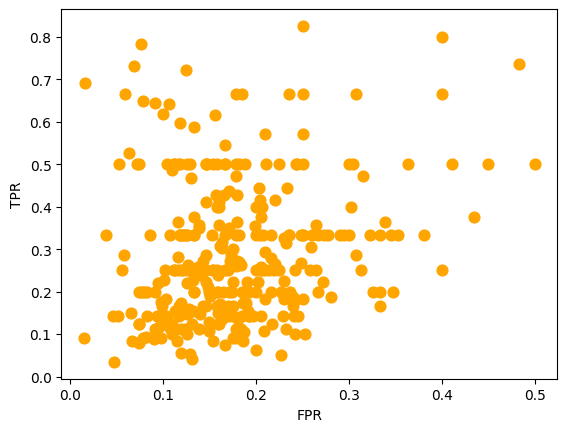

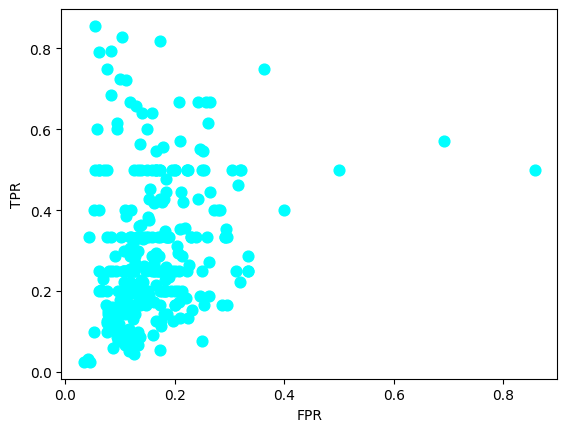

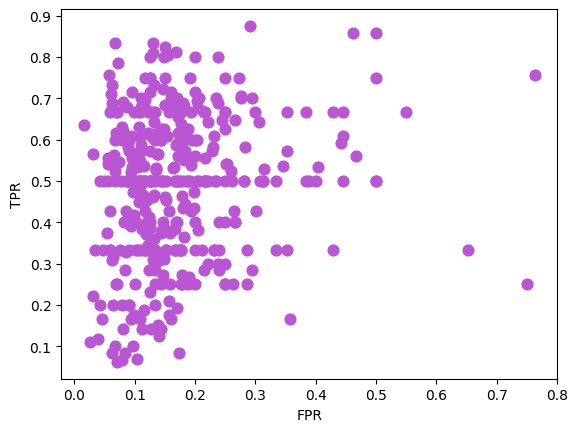

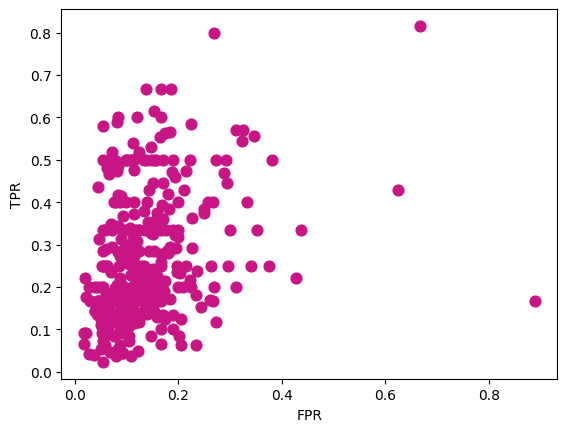

In [12]:
import numpy as np
#Students
Otherstudent.rename(columns={'title': 'useranswer'}, inplace=True)
Otherstudent.rename(columns={'goldstandardnew': 'correctanswer'}, inplace=True)
#creat TP TN FP FN for each pattern
conditions=[
     (Otherstudent['useranswer']=='gpd')&(Otherstudent['correctanswer']=='gpd'),
     (Otherstudent['useranswer']=='gpd')&(Otherstudent['correctanswer']!='gpd'),
     (Otherstudent['useranswer']!='gpd')&(Otherstudent['correctanswer']=='gpd'),
     (Otherstudent['useranswer']!='gpd')&(Otherstudent['correctanswer']!='gpd')
]

values=['TP','FP','FN','TN']
Otherstudent['GPD']=np.select(conditions,values)

conditions=[
     (Otherstudent['useranswer']=='lpd')&(Otherstudent['correctanswer']=='lpd'),
     (Otherstudent['useranswer']=='lpd')&(Otherstudent['correctanswer']!='lpd'),
     (Otherstudent['useranswer']!='lpd')&(Otherstudent['correctanswer']=='lpd'),
     (Otherstudent['useranswer']!='lpd')&(Otherstudent['correctanswer']!='lpd')
]

values=['TP','FP','FN','TN']
Otherstudent['LPD']=np.select(conditions,values)

conditions=[
     (Otherstudent['useranswer']=='lrda')&(Otherstudent['correctanswer']=='lrda'),
     (Otherstudent['useranswer']=='lrda')&(Otherstudent['correctanswer']!='lrda'),
     (Otherstudent['useranswer']!='lrda')&(Otherstudent['correctanswer']=='lrda'),
     (Otherstudent['useranswer']!='lrda')&(Otherstudent['correctanswer']!='lrda')
]

values=['TP','FP','FN','TN']
Otherstudent['lrda']=np.select(conditions,values)

conditions=[
     (Otherstudent['useranswer']=='grda')&(Otherstudent['correctanswer']=='grda'),
     (Otherstudent['useranswer']=='grda')&(Otherstudent['correctanswer']!='grda'),
     (Otherstudent['useranswer']!='grda')&(Otherstudent['correctanswer']=='grda'),
     (Otherstudent['useranswer']!='grda')&(Otherstudent['correctanswer']!='grda')
]

values=['TP','FP','FN','TN']
Otherstudent['grda']=np.select(conditions,values)

conditions=[
     (Otherstudent['useranswer']=='seizure')&(Otherstudent['correctanswer']=='seizure'),
     (Otherstudent['useranswer']=='seizure')&(Otherstudent['correctanswer']!='seizure'),
     (Otherstudent['useranswer']!='seizure')&(Otherstudent['correctanswer']=='seizure'),
     (Otherstudent['useranswer']!='seizure')&(Otherstudent['correctanswer']!='seizure')
]

values=['TP','FP','FN','TN']
Otherstudent['seizure']=np.select(conditions,values)

conditions=[
     (Otherstudent['useranswer']=='other')&(Otherstudent['correctanswer']=='other'),
     (Otherstudent['useranswer']=='other')&(Otherstudent['correctanswer']!='other'),
     (Otherstudent['useranswer']!='other')&(Otherstudent['correctanswer']=='other'),
     (Otherstudent['useranswer']!='other')&(Otherstudent['correctanswer']!='other')
]

values=['TP','FP','FN','TN']
Otherstudent['other']=np.select(conditions,values)

#create scatter plot
GPDOtherstudent1=Otherstudent[['user_id', 'GPD']].value_counts().reset_index(name='GPDcounts')
GPDOtherstudent2 = GPDOtherstudent1.pivot_table('GPDcounts', ['user_id'], 'GPD')
GPDOtherstudent2['TPR']=GPDOtherstudent2['TP']/(GPDOtherstudent2['TP']+GPDOtherstudent2['FN'])
GPDOtherstudent2['FPR']=GPDOtherstudent2['FP']/(GPDOtherstudent2['FP']+GPDOtherstudent2['TN'])
color='pink'
GPDOtherstudent2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LPDOtherstudent1=Otherstudent[['user_id', 'LPD']].value_counts().reset_index(name='LPDcounts')
LPDOtherstudent2 = LPDOtherstudent1.pivot_table('LPDcounts', ['user_id'], 'LPD')
LPDOtherstudent2['TPR']=LPDOtherstudent2['TP']/(LPDOtherstudent2['TP']+LPDOtherstudent2['FN'])
LPDOtherstudent2['FPR']=LPDOtherstudent2['FP']/(LPDOtherstudent2['FP']+LPDOtherstudent2['TN'])
color='purple'
LPDOtherstudent2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LRDAOtherstudent1=Otherstudent[['user_id', 'lrda']].value_counts().reset_index(name='LRDAcounts')
LRDAOtherstudent2 = LRDAOtherstudent1.pivot_table('LRDAcounts', ['user_id'], 'lrda')
LRDAOtherstudent2['TPR']=LRDAOtherstudent2['TP']/(LRDAOtherstudent2['TP']+LRDAOtherstudent2['FN'])
LRDAOtherstudent2['FPR']=LRDAOtherstudent2['FP']/(LRDAOtherstudent2['FP']+LRDAOtherstudent2['TN'])
color='orange'
LRDAOtherstudent2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

GRDAOtherstudent1=Otherstudent[['user_id', 'grda']].value_counts().reset_index(name='GRDAcounts')
GRDAOtherstudent2 = GRDAOtherstudent1.pivot_table('GRDAcounts', ['user_id'], 'grda')
GRDAOtherstudent2['TPR']=GRDAOtherstudent2['TP']/(GRDAOtherstudent2['TP']+GRDAOtherstudent2['FN'])
GRDAOtherstudent2['FPR']=GRDAOtherstudent2['FP']/(GRDAOtherstudent2['FP']+GRDAOtherstudent2['TN'])
color='aqua'
GRDAOtherstudent2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

seizureOtherstudent1=Otherstudent[['user_id', 'seizure']].value_counts().reset_index(name='seizurecounts')
seizureOtherstudent2 = seizureOtherstudent1.pivot_table('seizurecounts', ['user_id'], 'seizure')
seizureOtherstudent2['TPR']=seizureOtherstudent2['TP']/(seizureOtherstudent2['TP']+seizureOtherstudent2['FN'])
seizureOtherstudent2['FPR']=seizureOtherstudent2['FP']/(seizureOtherstudent2['FP']+seizureOtherstudent2['TN'])
color='mediumorchid'
seizureOtherstudent2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c= color)

otherOtherstudent1=Otherstudent[['user_id', 'other']].value_counts().reset_index(name='othercounts')
otherOtherstudent2 = otherOtherstudent1.pivot_table('othercounts', ['user_id'], 'other')
otherOtherstudent2['TPR']=otherOtherstudent2['TP']/(otherOtherstudent2['TP']+otherOtherstudent2['FN'])
otherOtherstudent2['FPR']=otherOtherstudent2['FP']/(otherOtherstudent2['FP']+otherOtherstudent2['TN'])
color='mediumvioletred'
otherOtherstudent2.plot.scatter(x = 'FPR', y = 'TPR', s = 60, c=color)

LPDOtherstudent2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\LPDOtherstudent2.csv', index=True, header=True)
GRDAOtherstudent2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\grdaOtherstudent2.csv', index=True, header=True)
LRDAOtherstudent2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\lrdaOtherstudent2.csv', index=True, header=True)
seizureOtherstudent2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\seizureOtherstudent2.csv', index=True, header=True)
GPDOtherstudent2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\GPDOtherstudent2.csv', index=True, header=True)
otherOtherstudent2.to_csv(r'C:\Users\wyeek\Desktop\research\westover\otherOtherstudent2.csv', index=True, header=True)